# Experimento 4: Validación Cruzada Espacial (Spatial K-Fold)

Evaluación de estabilidad del VAE con KMeans (K=3) mediante folds geográficos.

**Objetivo**: Determinar si el modelo generaliza entre regiones o depende de zonas específicas.

**Metodología**:
- Dividir el territorio en K folds geográficos
- Para cada fold: entrenar VAE, aplicar KMeans clustering, calcular métricas
- Analizar consistencia espacial del IRCT y estabilidad BASE→T585

**Métricas por fold**:
- Clustering interno: Silhouette, Calinski-Harabasz, Davies-Bouldin, Dunn
- Estabilidad BASE→T585: ARI, Jaccard, Drift, Stability
- IRCT: Mean, Std, CV, IQR, distribución

In [16]:
import os
import sys
import pickle
import re
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, jaccard_score
)
from scipy.spatial.distance import cdist, pdist
from scipy.stats import percentileofscore
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

# Importar librería oficial de resiliencia
from scripts.idroverdi_autoencoder_3.resilience_lib import compute_IRCT_pixel_wise

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "spatial_cv_analysis")
os.makedirs(PLOTS_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Directorio de plots: {PLOTS_DIR}")

Device: cuda
Directorio de plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/spatial_cv_analysis


## 1. Arquitectura VAE

In [17]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, p_drop=0.05):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(256, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    
    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar, z

def vae_loss(x, x_hat, mu, logvar, beta=0.5):
    recon = nn.MSELoss(reduction='mean')(x_hat, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

print("VAE definido")

VAE definido


## 2. Carga de datos BASE y T585

In [18]:
# Cargar datos desde archivos .npz (siguiendo estructura de idroverdi_autoencoder_3)
MODE = "full"  # Usar dataset completo
PATH_SSP585 = os.path.join(DATA_DIR, "autoencoder_tensors", f"tensors_ssp585_splits_{MODE}.npz")
PATH_FEATURE_NAMES = os.path.join(DATA_DIR, "autoencoder_tensors", f"feature_names_{MODE}.csv")
PATH_METADATA = os.path.join(DATA_DIR, "autoencoder_tensors", f"metadata_{MODE}.pkl")

def load_npz(path):
    """Carga y concatena splits de train/val/test desde .npz"""
    d = np.load(path)
    X = np.vstack([d["X_train"], d["X_val"], d["X_test"]])
    idx = np.concatenate([d["train_idx"], d["val_idx"], d["test_idx"]])
    return X, idx

# Cargar SSP585 (futuro) - será T585
X585_full, idx585 = load_npz(PATH_SSP585)

# Cargar feature names y metadata
feature_names = pd.read_csv(PATH_FEATURE_NAMES)["feature_name"].tolist()
with open(PATH_METADATA, "rb") as f:
    meta = pickle.load(f)

# Extraer coordenadas
mask = meta["mask"]
lat = meta["spatial_info"]["lat"]
lon = meta["spatial_info"]["lon"]
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing="ij")
flat_lat = lat_grid[mask]
flat_lon = lon_grid[mask]

# Coordenadas alineadas con los índices del split
coords_full = np.column_stack([flat_lat[idx585], flat_lon[idx585]])

# Construir BASE y T585 usando décadas
# BASE = década 2020 (presente/histórico)
# T585 = décadas futuras (2050, 2080) para SSP585

DEC_BASE = [2020]
DEC_TARGET = [2050, 2080]

def cols_for_decades(names, decades):
    """Extrae índices de features decadales para décadas específicas"""
    pat = re.compile(r"_decadal_(?:mean|max|min)_(\d{4})$")
    idx = []
    for j, n in enumerate(names):
        m = pat.search(n)
        if m and int(m.group(1)) in decades:
            idx.append(j)
    return idx

def non_decadal_idx(names):
    """Extrae índices de features NO decadales (estáticas)"""
    return [j for j, n in enumerate(names) if "_decadal_" not in n]

base_idx = cols_for_decades(feature_names, DEC_BASE)
tgt_idx = cols_for_decades(feature_names, DEC_TARGET)
non_idx = non_decadal_idx(feature_names)

# Construir BASE (2020 + estáticas) y T585 (2050+2080 + estáticas)
X_base = np.hstack([X585_full[:, base_idx], X585_full[:, non_idx]])
X_t585 = np.hstack([X585_full[:, tgt_idx], X585_full[:, non_idx]])

coords_base = coords_full
coords_t585 = coords_full  # Mismas coordenadas para ambos periodos

print(f"BASE (2020): {X_base.shape}")
print(f"T585 (2050+2080): {X_t585.shape}")
print(f"Coords: {coords_base.shape}")
print(f"Features BASE: {len(base_idx)} decadales + {len(non_idx)} estáticas = {X_base.shape[1]}")
print(f"Features T585: {len(tgt_idx)} decadales + {len(non_idx)} estáticas = {X_t585.shape[1]}")

assert X_base.shape[0] == coords_base.shape[0], "Mismatch samples-coords BASE"
assert X_t585.shape[0] == coords_t585.shape[0], "Mismatch samples-coords T585"
assert X_base.shape[0] == X_t585.shape[0], "Mismatch samples entre BASE y T585"

BASE (2020): (661, 29)
T585 (2050+2080): (661, 38)
Coords: (661, 2)
Features BASE: 9 decadales + 20 estáticas = 29
Features T585: 18 decadales + 20 estáticas = 38


## 3. Creación de folds geográficos espaciales

In [19]:
def create_spatial_folds(coords, n_folds=5):
    """
    Divide el territorio en folds geográficos basados en latitud.
    Retorna lista de índices por fold.
    """
    lats = coords[:, 0]
    lat_sorted_idx = np.argsort(lats)
    
    fold_indices = []
    fold_size = len(lat_sorted_idx) // n_folds
    
    for i in range(n_folds):
        start = i * fold_size
        end = start + fold_size if i < n_folds - 1 else len(lat_sorted_idx)
        fold_indices.append(lat_sorted_idx[start:end])
    
    return fold_indices

N_FOLDS = 5
folds = create_spatial_folds(coords_base, n_folds=N_FOLDS)

print(f"Creados {N_FOLDS} folds espaciales")
for i, fold_idx in enumerate(folds):
    lat_range = (coords_base[fold_idx, 0].min(), coords_base[fold_idx, 0].max())
    print(f"Fold {i+1}: {len(fold_idx)} puntos, lat [{lat_range[0]:.4f}, {lat_range[1]:.4f}]")

Creados 5 folds espaciales
Fold 1: 132 puntos, lat [-33.2250, -33.0750]
Fold 2: 132 puntos, lat [-33.0750, -32.8750]
Fold 3: 132 puntos, lat [-32.8750, -32.6750]
Fold 4: 132 puntos, lat [-32.6750, -32.4750]
Fold 5: 133 puntos, lat [-32.4750, -32.2750]


## 3.5. Visualización de folds geográficos

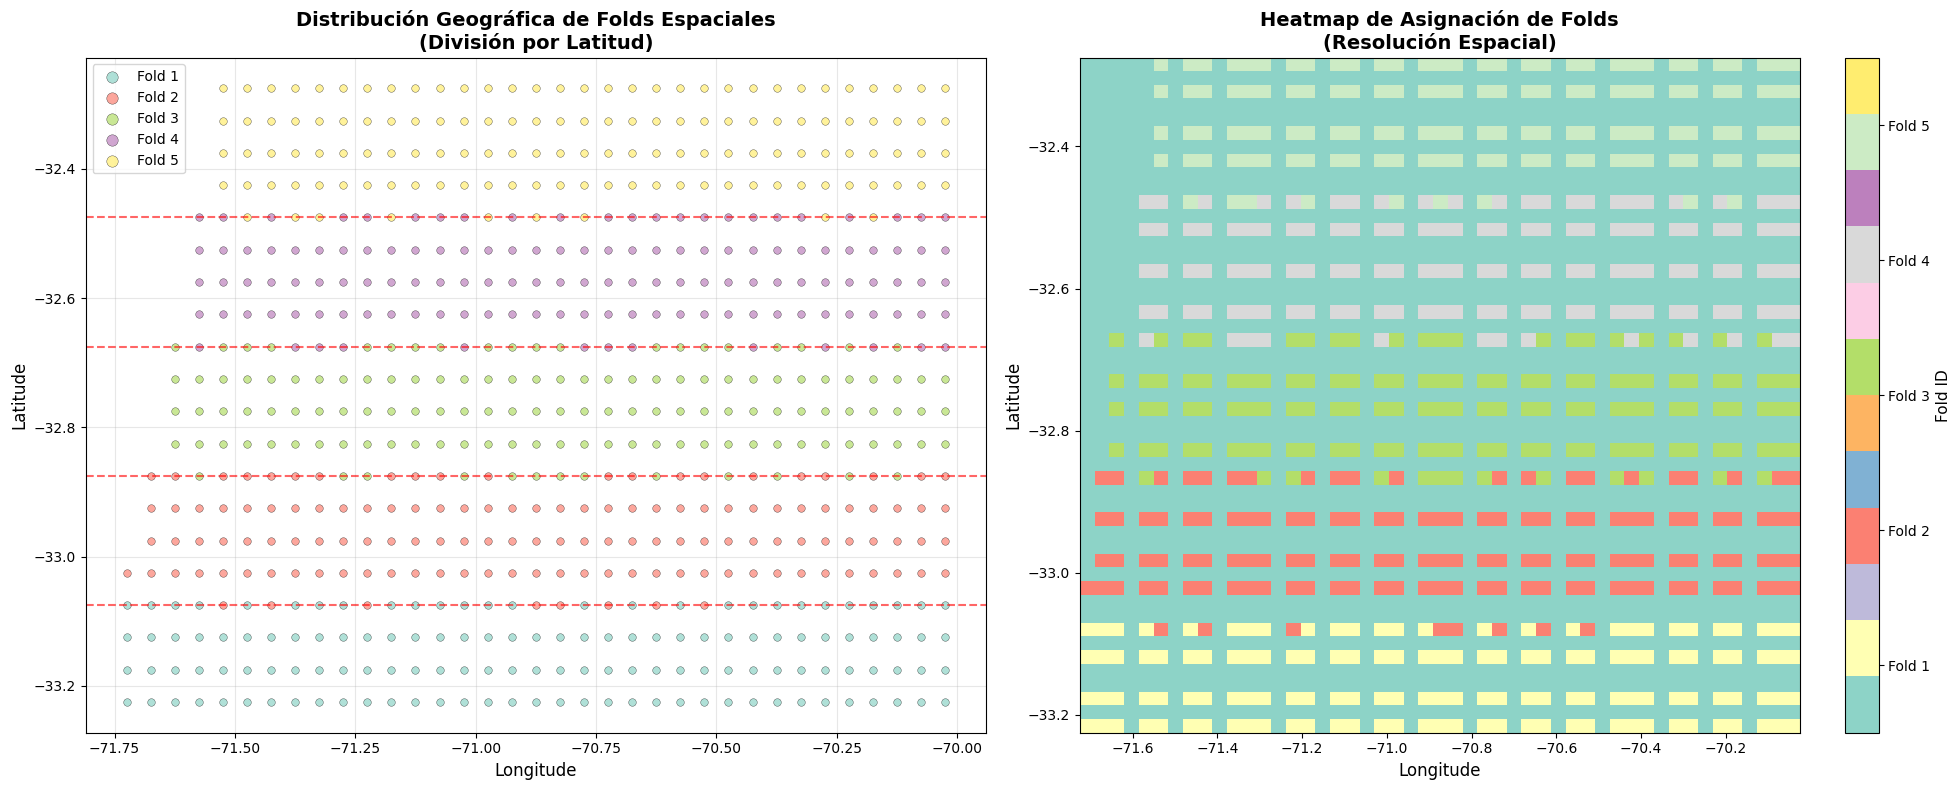

Visualización de folds geográficos guardada

Características de la división espacial:
  - División por latitud en 5 bandas horizontales
  - Cada fold cubre un rango latitudinal continuo
  - Permite evaluar dependencia Norte-Sur del modelo


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Panel 1: Mapa de folds geográficos
ax1 = axes[0]
colors_folds = plt.cm.Set3(np.linspace(0, 1, N_FOLDS))

for i, fold_idx in enumerate(folds):
    coords_fold = coords_base[fold_idx]
    ax1.scatter(coords_fold[:, 1], coords_fold[:, 0], 
               c=[colors_folds[i]], 
               label=f'Fold {i+1}', 
               s=30, alpha=0.7, edgecolors='black', linewidths=0.3)

ax1.set_title('Distribución Geográfica de Folds Espaciales\n(División por Latitud)', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.legend(loc='best', fontsize=10, markerscale=1.5)
ax1.grid(True, alpha=0.3)

# Agregar líneas divisorias entre folds
for i in range(1, N_FOLDS):
    lat_boundary = coords_base[folds[i], 0].min()
    ax1.axhline(y=lat_boundary, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

# Panel 2: Heatmap de densidad de puntos por fold
ax2 = axes[1]

# Crear matriz de asignación fold por coordenadas
lat_bins = np.linspace(coords_base[:, 0].min(), coords_base[:, 0].max(), 50)
lon_bins = np.linspace(coords_base[:, 1].min(), coords_base[:, 1].max(), 50)

fold_assignment = np.zeros(len(coords_base))
for i, fold_idx in enumerate(folds):
    fold_assignment[fold_idx] = i + 1

# Crear heatmap con fold assignment
heatmap, xedges, yedges = np.histogram2d(
    coords_base[:, 1], coords_base[:, 0], 
    bins=[lon_bins, lat_bins], 
    weights=fold_assignment
)

# Normalizar por número de puntos en cada celda
counts, _, _ = np.histogram2d(coords_base[:, 1], coords_base[:, 0], bins=[lon_bins, lat_bins])
heatmap_norm = np.divide(heatmap, counts, where=counts>0, out=np.zeros_like(heatmap))

im = ax2.imshow(heatmap_norm.T, origin='lower', 
               extent=[lon_bins.min(), lon_bins.max(), lat_bins.min(), lat_bins.max()],
               cmap='Set3', aspect='auto', interpolation='nearest', vmin=0.5, vmax=N_FOLDS+0.5)

ax2.set_title('Heatmap de Asignación de Folds\n(Resolución Espacial)', 
             fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)

cbar = plt.colorbar(im, ax=ax2, ticks=np.arange(1, N_FOLDS+1))
cbar.set_label('Fold ID', fontsize=11)
cbar.ax.set_yticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "spatial_folds_geographic_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Visualización de folds geográficos guardada")
print(f"\nCaracterísticas de la división espacial:")
print(f"  - División por latitud en {N_FOLDS} bandas horizontales")
print(f"  - Cada fold cubre un rango latitudinal continuo")
print(f"  - Permite evaluar dependencia Norte-Sur del modelo")

## 3.6. Caracterización detallada de folds geográficos

CARACTERÍSTICAS GEOGRÁFICAS DE LOS FOLDS
  Fold  N_Puntos  Lat_Min  Lat_Max  Lat_Range   Lat_Mean  Lon_Min  Lon_Max  Lon_Range   Lon_Mean
Fold_1       132  -33.225  -33.075       0.15 -33.154545  -71.725  -70.025       1.70 -70.869318
Fold_2       132  -33.075  -32.875       0.20 -32.965530  -71.725  -70.025       1.70 -70.869318
Fold_3       132  -32.875  -32.675       0.20 -32.769697  -71.625  -70.025       1.60 -70.829545
Fold_4       132  -32.675  -32.475       0.20 -32.567424  -71.575  -70.025       1.55 -70.785606
Fold_5       133  -32.475  -32.275       0.20 -32.358459  -71.525  -70.025       1.50 -70.785902


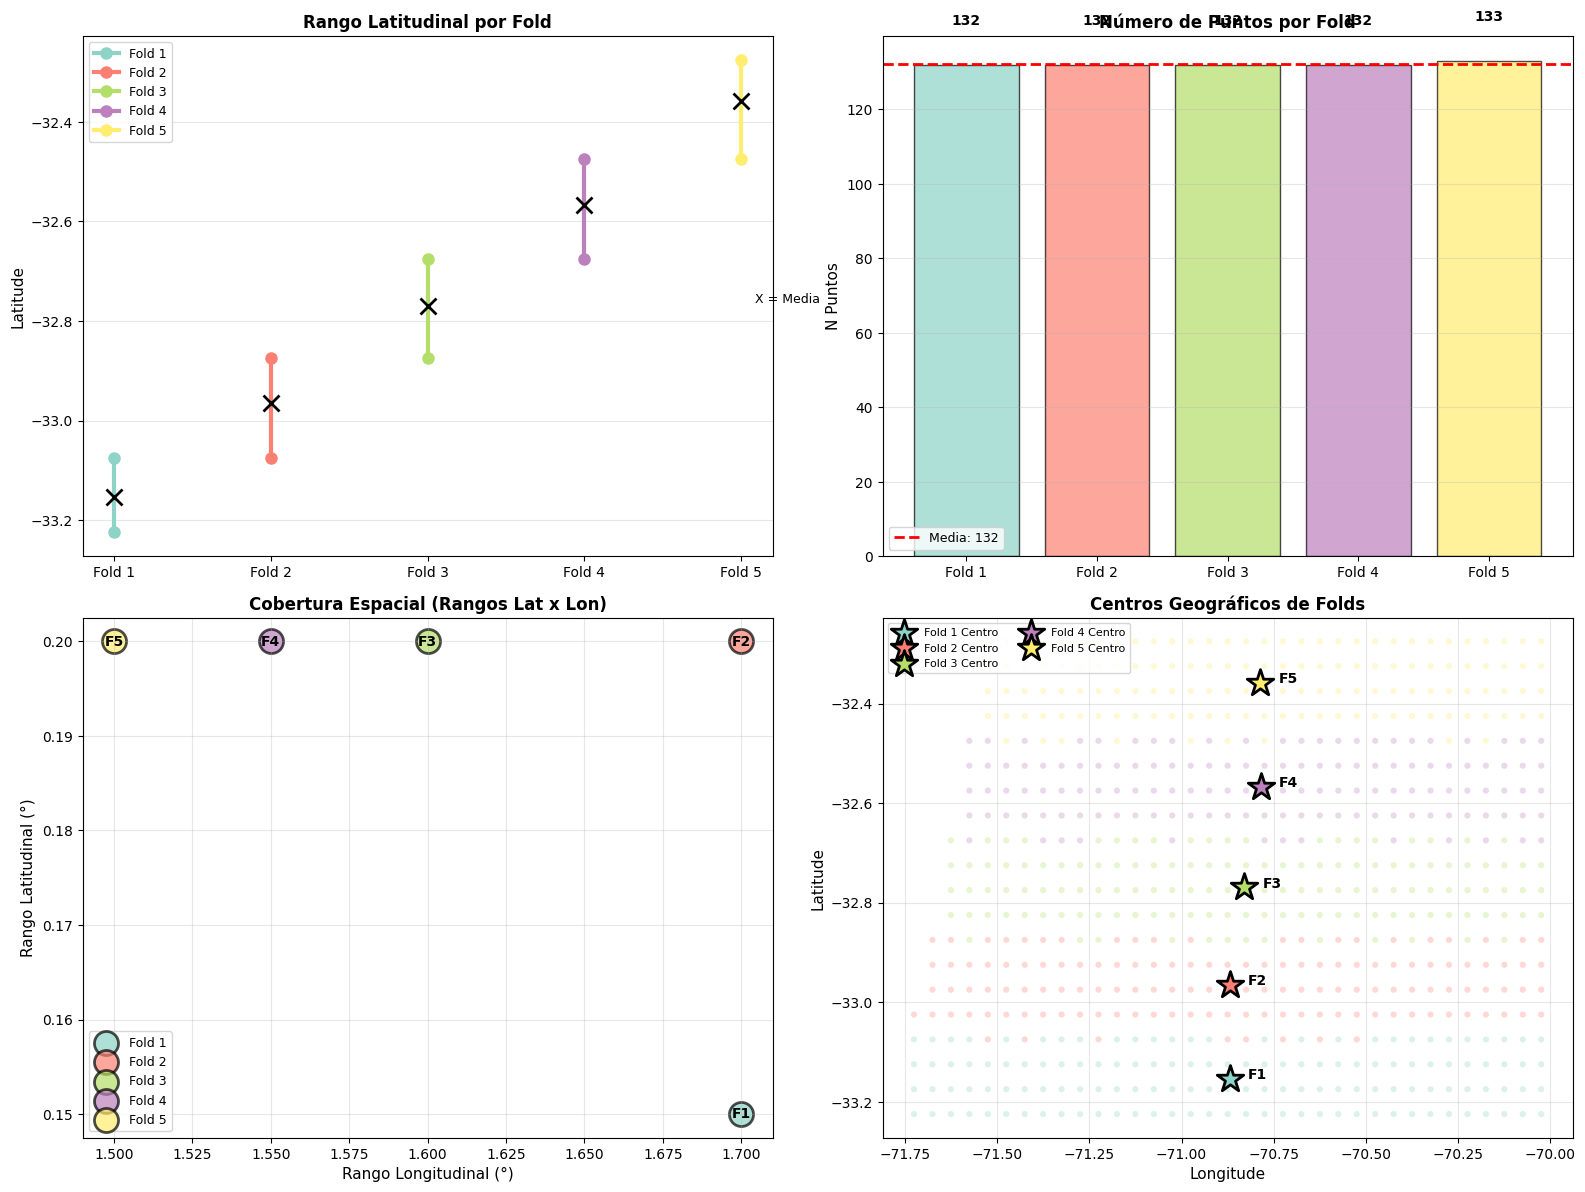


Archivos guardados:
  - spatial_folds_detailed_characterization.png
  - spatial_folds_characteristics.csv

Análisis de homogeneidad espacial:
  - CV de número de puntos: 0.0030
  - CV de rango latitudinal: 0.1053
  - Cobertura longitudinal similar: 0.0497


In [21]:
# Tabla de características por fold
fold_characteristics = []

for i, fold_idx in enumerate(folds):
    coords_fold = coords_base[fold_idx]
    
    char = {
        'Fold': f'Fold_{i+1}',
        'N_Puntos': len(fold_idx),
        'Lat_Min': coords_fold[:, 0].min(),
        'Lat_Max': coords_fold[:, 0].max(),
        'Lat_Range': coords_fold[:, 0].max() - coords_fold[:, 0].min(),
        'Lat_Mean': coords_fold[:, 0].mean(),
        'Lon_Min': coords_fold[:, 1].min(),
        'Lon_Max': coords_fold[:, 1].max(),
        'Lon_Range': coords_fold[:, 1].max() - coords_fold[:, 1].min(),
        'Lon_Mean': coords_fold[:, 1].mean()
    }
    fold_characteristics.append(char)

df_folds = pd.DataFrame(fold_characteristics)

print("CARACTERÍSTICAS GEOGRÁFICAS DE LOS FOLDS")
print("="*80)
print(df_folds.to_string(index=False))

# Visualización de rangos latitudinales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Rango latitudinal por fold
ax1 = axes[0, 0]
fold_names = [f"Fold {i+1}" for i in range(N_FOLDS)]
lat_mins = df_folds['Lat_Min'].values
lat_maxs = df_folds['Lat_Max'].values
lat_means = df_folds['Lat_Mean'].values

for i in range(N_FOLDS):
    ax1.plot([i, i], [lat_mins[i], lat_maxs[i]], 'o-', linewidth=3, markersize=8, 
            color=colors_folds[i], label=f'Fold {i+1}')
    ax1.plot(i, lat_means[i], 'x', markersize=12, color='black', markeredgewidth=2)

ax1.set_title('Rango Latitudinal por Fold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_xticks(range(N_FOLDS))
ax1.set_xticklabels(fold_names)
ax1.legend(loc='best', fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.text(N_FOLDS - 0.5, lat_means.mean(), 'X = Media', fontsize=9, ha='right')

# Panel 2: Número de puntos por fold
ax2 = axes[0, 1]
n_points = df_folds['N_Puntos'].values
bars = ax2.bar(fold_names, n_points, color=colors_folds, alpha=0.7, edgecolor='black')

ax2.axhline(y=np.mean(n_points), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(n_points):.0f}')
ax2.set_title('Número de Puntos por Fold', fontsize=12, fontweight='bold')
ax2.set_ylabel('N Puntos', fontsize=11)
ax2.legend(loc='best', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, n_points)):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 10, f'{val}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 3: Cobertura espacial (lat x lon) por fold
ax3 = axes[1, 0]
lat_ranges = df_folds['Lat_Range'].values
lon_ranges = df_folds['Lon_Range'].values

for i in range(N_FOLDS):
    ax3.scatter(lon_ranges[i], lat_ranges[i], s=300, color=colors_folds[i], 
               alpha=0.7, edgecolors='black', linewidths=2, label=f'Fold {i+1}')
    ax3.text(lon_ranges[i], lat_ranges[i], f'F{i+1}', ha='center', va='center', 
            fontsize=10, fontweight='bold')

ax3.set_title('Cobertura Espacial (Rangos Lat x Lon)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Rango Longitudinal (°)', fontsize=11)
ax3.set_ylabel('Rango Latitudinal (°)', fontsize=11)
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# Panel 4: Centros geográficos de cada fold
ax4 = axes[1, 1]

for i, fold_idx in enumerate(folds):
    coords_fold = coords_base[fold_idx]
    ax4.scatter(coords_fold[:, 1], coords_fold[:, 0], 
               c=[colors_folds[i]], s=20, alpha=0.3, edgecolors='none')
    
    # Marcar centro geográfico
    center_lon = coords_fold[:, 1].mean()
    center_lat = coords_fold[:, 0].mean()
    ax4.scatter(center_lon, center_lat, s=400, color=colors_folds[i], 
               marker='*', edgecolors='black', linewidths=2, 
               label=f'Fold {i+1} Centro', zorder=10)
    ax4.text(center_lon + 0.05, center_lat, f'F{i+1}', fontsize=10, fontweight='bold')

ax4.set_title('Centros Geográficos de Folds', fontsize=12, fontweight='bold')
ax4.set_xlabel('Longitude', fontsize=11)
ax4.set_ylabel('Latitude', fontsize=11)
ax4.legend(loc='best', fontsize=8, ncol=2)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "spatial_folds_detailed_characterization.png"), dpi=300, bbox_inches='tight')
plt.show()

# Guardar tabla
df_folds.to_csv(os.path.join(PLOTS_DIR, "spatial_folds_characteristics.csv"), index=False)

print(f"\nArchivos guardados:")
print(f"  - spatial_folds_detailed_characterization.png")
print(f"  - spatial_folds_characteristics.csv")

print(f"\nAnálisis de homogeneidad espacial:")
print(f"  - CV de número de puntos: {np.std(n_points) / np.mean(n_points):.4f}")
print(f"  - CV de rango latitudinal: {np.std(lat_ranges) / np.mean(lat_ranges):.4f}")
print(f"  - Cobertura longitudinal similar: {np.std(lon_ranges) / np.mean(lon_ranges):.4f}")

## 4. Funciones de métricas de clustering

In [22]:
def compute_dunn_index(X, labels):
    """Dunn Index: max_intra / min_inter"""
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0
    
    intra_dists = []
    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 1:
            intra_dists.append(np.max(pdist(cluster_points)))
    
    if not intra_dists:
        return 0.0
    max_intra = np.max(intra_dists)
    
    inter_dists = []
    for i, label_i in enumerate(unique_labels):
        for label_j in unique_labels[i+1:]:
            center_i = X[labels == label_i].mean(axis=0)
            center_j = X[labels == label_j].mean(axis=0)
            inter_dists.append(np.linalg.norm(center_i - center_j))
    
    if not inter_dists or max_intra == 0:
        return 0.0
    min_inter = np.min(inter_dists)
    
    return min_inter / max_intra

def compute_clustering_metrics(X, labels):
    """Calcula Silhouette, Calinski-Harabasz, Davies-Bouldin, Dunn"""
    metrics = {}
    try:
        metrics['silhouette'] = silhouette_score(X, labels)
    except:
        metrics['silhouette'] = np.nan
    
    try:
        metrics['calinski_harabasz'] = calinski_harabasz_score(X, labels)
    except:
        metrics['calinski_harabasz'] = np.nan
    
    try:
        metrics['davies_bouldin'] = davies_bouldin_score(X, labels)
    except:
        metrics['davies_bouldin'] = np.nan
    
    try:
        metrics['dunn'] = compute_dunn_index(X, labels)
    except:
        metrics['dunn'] = np.nan
    
    return metrics

print("Funciones de métricas de clustering definidas")

Funciones de métricas de clustering definidas


## 5. Funciones de estabilidad BASE → T585

In [23]:
def compute_jaccard_per_cluster(labels_base, labels_t585, k):
    """Jaccard promedio por cluster"""
    jaccards = []
    for c in range(k):
        set_base = set(np.where(labels_base == c)[0])
        set_t585 = set(np.where(labels_t585 == c)[0])
        if len(set_base) > 0 or len(set_t585) > 0:
            intersection = len(set_base & set_t585)
            union = len(set_base | set_t585)
            jaccards.append(intersection / union if union > 0 else 0.0)
    return np.mean(jaccards) if jaccards else 0.0

def compute_drift(Z_base, Z_t585, labels_base, labels_t585, k):
    """Drift promedio de centroides BASE → T585"""
    drifts = []
    for c in range(k):
        center_base = Z_base[labels_base == c].mean(axis=0)
        center_t585 = Z_t585[labels_t585 == c].mean(axis=0)
        drifts.append(np.linalg.norm(center_base - center_t585))
    return np.mean(drifts)

def compute_stability_metrics(labels_base, labels_t585, Z_base, Z_t585, k):
    """Calcula ARI, Jaccard, Drift, Stability"""
    metrics = {}
    metrics['ARI_T585'] = adjusted_rand_score(labels_base, labels_t585)
    metrics['Avg_Jaccard_T585'] = compute_jaccard_per_cluster(labels_base, labels_t585, k)
    metrics['Avg_Drift_T585'] = compute_drift(Z_base, Z_t585, labels_base, labels_t585, k)
    metrics['Avg_Stability_T585'] = 1.0 - metrics['Avg_Drift_T585'] / (1.0 + metrics['Avg_Drift_T585'])
    return metrics

print("Funciones de estabilidad BASE→T585 definidas")

Funciones de estabilidad BASE→T585 definidas


## 6. Funciones de entrenamiento VAE y clustering KMeans

In [24]:
def train_vae(X_train, latent_dim=12, epochs=200, lr=0.001, beta=0.5, batch_size=64):
    """Entrena VAE y retorna modelo + representación latente"""
    model = VAE(input_dim=X_train.shape[1], latent_dim=latent_dim, p_drop=0.05).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    X_tensor = torch.FloatTensor(X_train).to(device)
    dataset = torch.utils.data.TensorDataset(X_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch_x,) in loader:
            optimizer.zero_grad()
            x_hat, mu, logvar, z = model(batch_x)
            loss, recon, kl = vae_loss(batch_x, x_hat, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        scheduler.step(avg_loss)
        
        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_train).to(device)
        _, mu, _, _ = model(X_tensor)
        Z_train = mu.cpu().numpy()
    
    return model, Z_train

def apply_kmeans_clustering(Z, k=3):
    """
    Aplica KMeans directamente sobre representación latente Z.
    
    Estrategia:
    1. Normalizar Z con StandardScaler para igualar importancia de dimensiones
    2. KMeans directo sobre Z (12D) con n_init=50 para estabilidad
    3. Garantiza exactamente K clusters distintos
    
    Args:
        Z: representación latente del VAE (n_samples, latent_dim)
        k: número de clusters
    
    Returns:
        labels: etiquetas de cluster (0 a k-1)
        kmeans: objeto KMeans entrenado
    """
    # Normalizar Z para mejor clustering
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    Z_scaled = scaler.fit_transform(Z)
    
    # KMeans directo sobre espacio latente
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=50, max_iter=500)
    labels = kmeans.fit_predict(Z_scaled)
    

    return labels, kmeans

print("Funciones de entrenamiento VAE y KMeans definidas")

Funciones de entrenamiento VAE y KMeans definidas


## 7. Función de cálculo de IRCT (usando librería oficial)

In [25]:
def compute_irct_indicators(vae_base, vae_t585, X_base_fold, X_t585_fold, Z_base, Z_t585, labels_base, centroids_base, k=3):
    """
    Calcula el IRCT (Índice de Resiliencia Climático-Territorial) usando la librería oficial.
    
    IRCT = (A^w_a) * (S_D^w_d) * (S_C^w_c) * (S_E^w_e)
    
    Donde:
    - A (15%): Anomalía de reconstrucción
    - S_D (30%): Desplazamiento latente (1 / (1 + distancia_al_centroide))
    - S_C (25%): Estabilidad de cluster (probabilidad softmax)
    - S_E (20%): Expansión del cluster (inverso de razón std_future/std_base)
    
    Nota: Usamos el modelo VAE_T585 para calcular la anomalía de reconstrucción en T585.
    """
    # Calcular IRCT usando librería oficial
    irct_results = compute_IRCT_pixel_wise(
        model=vae_t585,  # Usar VAE_T585 para reconstrucción de futuro
        X_base_orig=X_base_fold,
        X_base_norm=X_base_fold,  # Ya está normalizado en el pipeline
        X_future_orig=X_t585_fold,
        X_future_norm=X_t585_fold,  # Ya está normalizado
        z_base_scaled=Z_base,
        z_future_scaled=Z_t585,
        centroids_base=centroids_base,
        labels_base=labels_base,
        h2_base=None,  # Sin datos de H₂ en este experimento
        h2_future=None,
        weights=None,  # Usar pesos por defecto
        device=device,
        inv_covs_base=None,  # Sin matrices de covarianza
        recon_use_normalized=True,
        inverse_transform=None,
        softmax_tau=1.0,
        expansion_p99_clip=False,
        h2_p99_clip=True,
        eps=1e-8
    )
    
    # Extraer IRCT (ya normalizado en [0, 1] por resilience_lib.py)
    irct_scores = irct_results['IRCT']
    print(f"[DEBUG] irct_scores range: [{irct_scores.min():.6f}, {irct_scores.max():.6f}]")
    
    indicators = {
        'IRCT_Mean': np.mean(irct_scores),
        'IRCT_Std': np.std(irct_scores),
        'IRCT_CV': np.std(irct_scores) / np.mean(irct_scores) if np.mean(irct_scores) > 0 else np.nan,
        'IRCT_IQR': np.percentile(irct_scores, 75) - np.percentile(irct_scores, 25),
        'IRCT_Min': np.min(irct_scores),
        'IRCT_Max': np.max(irct_scores),
        'IRCT_Q25': np.percentile(irct_scores, 25),
        'IRCT_Q50': np.percentile(irct_scores, 50),
        'IRCT_Q75': np.percentile(irct_scores, 75),
    }
    
    return indicators, irct_scores

print("Función de cálculo de IRCT definida")


Función de cálculo de IRCT definida


## 8. Pipeline de validación cruzada espacial

In [26]:
def run_spatial_cv_fold(fold_idx, X_base_full, X_t585_full, k=3, latent_dim=12, fold_name="Fold"):
    """
    Ejecuta validación cruzada para un fold:
    1. Entrena VAE_BASE en BASE (29 features)
    2. Entrena VAE_T585 en T585 (38 features)
    3. Aplica KMeans clustering directo a cada espacio latente
    4. Calcula métricas de clustering interno
    5. Calcula estabilidad BASE→T585
    6. Calcula indicadores IRCT
    """
    print(f"\n{fold_name}: {len(fold_idx)} puntos")
    
    X_base_fold = X_base_full[fold_idx]
    X_t585_fold = X_t585_full[fold_idx]
    
    # Entrenar VAE para BASE (29 features)
    print(f"  Entrenando VAE_BASE (input_dim={X_base_fold.shape[1]}, latent_dim={latent_dim})...")
    vae_base, Z_base = train_vae(X_base_fold, latent_dim=latent_dim, epochs=200, lr=0.001, beta=0.5, batch_size=64)
    
    # Entrenar VAE para T585 (38 features)
    print(f"  Entrenando VAE_T585 (input_dim={X_t585_fold.shape[1]}, latent_dim={latent_dim})...")
    vae_t585, Z_t585 = train_vae(X_t585_fold, latent_dim=latent_dim, epochs=200, lr=0.001, beta=0.5, batch_size=64)
    
    print(f"  Aplicando KMeans clustering (K={k})...")
    labels_base, kmeans_base = apply_kmeans_clustering(Z_base, k=k)
    labels_t585, _ = apply_kmeans_clustering(Z_t585, k=k)
    
    print(f"  Calculando métricas de clustering interno (BASE)...")
    clustering_metrics = compute_clustering_metrics(Z_base, labels_base)
    
    print(f"  Calculando estabilidad BASE→T585...")
    stability_metrics = compute_stability_metrics(labels_base, labels_t585, Z_base, Z_t585, k)
    
    print(f"  Calculando indicadores IRCT...")
    irt_indicators, irt_scores = compute_irct_indicators(
        vae_base, vae_t585, X_base_fold, X_t585_fold, 
        Z_base, Z_t585, labels_base, 
        kmeans_base.cluster_centers_, k
    )
    
    results = {
        'fold_name': fold_name,
        'n_points': len(fold_idx),
        'clustering': clustering_metrics,
        'stability': stability_metrics,
        'irt': irt_indicators,
        'irt_scores': irt_scores,
        'labels_base': labels_base,
        'labels_t585': labels_t585,
        'Z_base': Z_base,
        'Z_t585': Z_t585
    }
    
    return results

print("Función de pipeline por fold definida (con VAEs separados para BASE y T585)")


Función de pipeline por fold definida (con VAEs separados para BASE y T585)


## 8.5. Test rápido de clustering (diagnóstico)

In [27]:
# Test con primer fold para verificar que clustering genera K clusters distintos
print("Test de clustering con Fold_1:")
test_fold_idx = folds[0]
X_test = X_base[test_fold_idx]

print(f"Entrenando VAE en {len(test_fold_idx)} puntos...")
_, Z_test = train_vae(X_test, latent_dim=12, epochs=50, lr=0.001, beta=0.5, batch_size=32)

print(f"Aplicando KMeans clustering directo sobre Z (K=3)...")
labels_test, _ = apply_kmeans_clustering(Z_test, k=3)

print(f"\nDistribución de clusters:")
unique, counts = np.unique(labels_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} puntos ({100*c/len(labels_test):.1f}%)")

print(f"\nNúmero de clusters únicos: {len(unique)}")
if len(unique) < 3:
    print("ERROR: Menos de K=3 clusters generados. El espacio latente no es separable.")
    print("Posible causa: datos muy homogéneos o VAE colapsado.")
else:
    print("OK: Se generaron 3 clusters distintos.")
    
    # Calcular métricas de clustering
    from sklearn.metrics import silhouette_score, calinski_harabasz_score
    sil = silhouette_score(Z_test, labels_test)
    ch = calinski_harabasz_score(Z_test, labels_test)
    print(f"\nMétricas de clustering:")
    print(f"  Silhouette: {sil:.4f}")
    print(f"  Calinski-Harabasz: {ch:.2f}")


Test de clustering con Fold_1:
Entrenando VAE en 132 puntos...
  Epoch 50/50, Loss: 0.273806
Aplicando KMeans clustering directo sobre Z (K=3)...

Distribución de clusters:
  Cluster 0: 60 puntos (45.5%)
  Cluster 1: 36 puntos (27.3%)
  Cluster 2: 36 puntos (27.3%)

Número de clusters únicos: 3
OK: Se generaron 3 clusters distintos.

Métricas de clustering:
  Silhouette: 0.6127
  Calinski-Harabasz: 357.85


## 9. Ejecución de validación cruzada espacial (K=5 folds)

In [28]:
K_CLUSTERS = 3
LATENT_DIM = 12

cv_results = []

print(f"Ejecutando validación cruzada espacial con {N_FOLDS} folds")
print(f"K={K_CLUSTERS}, latent_dim={LATENT_DIM}")

for i, fold_idx in enumerate(folds):
    fold_name = f"Fold_{i+1}"
    results = run_spatial_cv_fold(
        fold_idx=fold_idx,
        X_base_full=X_base,
        X_t585_full=X_t585,
        k=K_CLUSTERS,
        latent_dim=LATENT_DIM,
        fold_name=fold_name
    )
    cv_results.append(results)
    
    print(f"\n{fold_name} completado:")
    print(f"  Silhouette: {results['clustering']['silhouette']:.4f}")
    print(f"  Calinski-Harabasz: {results['clustering']['calinski_harabasz']:.2f}")
    print(f"  Davies-Bouldin: {results['clustering']['davies_bouldin']:.4f}")
    print(f"  Dunn: {results['clustering']['dunn']:.4f}")
    print(f"  ARI_T585: {results['stability']['ARI_T585']:.4f}")
    print(f"  IRCT_Mean: {results['irt']['IRCT_Mean']:.2f}")
    print(f"  IRCT_Std: {results['irt']['IRCT_Std']:.2f}")

print(f"\nValidación cruzada espacial completada")

Ejecutando validación cruzada espacial con 5 folds
K=3, latent_dim=12

Fold_1: 132 puntos
  Entrenando VAE_BASE (input_dim=29, latent_dim=12)...
  Epoch 50/200, Loss: 0.433504
  Epoch 100/200, Loss: 0.275623
  Epoch 150/200, Loss: 0.235422
  Epoch 200/200, Loss: 0.250873
  Entrenando VAE_T585 (input_dim=38, latent_dim=12)...
  Epoch 50/200, Loss: 0.416452
  Epoch 100/200, Loss: 0.273030
  Epoch 150/200, Loss: 0.250931
  Epoch 200/200, Loss: 0.233339
  Aplicando KMeans clustering (K=3)...
  Calculando métricas de clustering interno (BASE)...
  Calculando estabilidad BASE→T585...
  Calculando indicadores IRCT...

[DEBUG compute_reconstruction_anomaly]
  model type: VAE
  X_orig shape: (132, 38)
  X_normalized shape: (132, 38)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expansion] Retornando 132 valores únicos de 132 píxeles
[DEBUG] irct_scores range: [0.000000, 0.584138]

Fold_1 completado:
  Silhouette: 0.6329
  Calinsk

## 10. Agregación de resultados por métrica

## 11. Tabla de resultados por fold


In [32]:
df_rows = []
for r in cv_results:
    row = {
        'Fold': r['fold_name'],
        'N_Points': r['n_points'],
        'Silhouette': r['clustering']['silhouette'],
        'Calinski_Harabasz': r['clustering']['calinski_harabasz'],
        'Davies_Bouldin': r['clustering']['davies_bouldin'],
        'Dunn': r['clustering']['dunn'],
        'ARI_T585': r['stability']['ARI_T585'],
        'Jaccard_T585': r['stability']['Avg_Jaccard_T585'],
        'Drift_T585': r['stability']['Avg_Drift_T585'],
        'Stability_T585': r['stability']['Avg_Stability_T585'],
        'IRCT_Mean': r['irt']['IRCT_Mean'],
        'IRCT_Std': r['irt']['IRCT_Std'],
        'IRCT_CV': r['irt']['IRCT_CV'],
        'IRCT_IQR': r['irt']['IRCT_IQR']
    }
    df_rows.append(row)

df_summary = pd.DataFrame(df_rows)
print("\nTabla de resultados por fold:")
print(df_summary.to_string(index=False))

df_summary.to_csv(os.path.join(PLOTS_DIR, "spatial_cv_results_by_fold.csv"), index=False)
print(f"\nGuardado: spatial_cv_results_by_fold.csv")


Tabla de resultados por fold:
  Fold  N_Points  Silhouette  Calinski_Harabasz  Davies_Bouldin     Dunn  ARI_T585  Jaccard_T585  Drift_T585  Stability_T585  IRCT_Mean  IRCT_Std  IRCT_CV  IRCT_IQR
Fold_1       132    0.632937         387.176849        0.497917 1.014111  0.885214      0.328062    2.410350        0.293225   0.325381  0.123149 0.378477  0.167252
Fold_2       132    0.582573         291.188293        0.536396 0.839262  0.436663      0.200913    1.860983        0.349530   0.331928  0.120917 0.364287  0.216017
Fold_3       132    0.665153         416.035645        0.446802 1.022173  0.927844      0.321886    2.630458        0.275447   0.289448  0.111086 0.383787  0.166399
Fold_4       132    0.634231         367.920959        0.470925 0.918464  0.844075      0.900424    1.835241        0.352704   0.368800  0.118213 0.320534  0.136809
Fold_5       133    0.565257         324.131470        0.558619 0.875014  0.688970      0.258706    1.840206        0.352087   0.295713  0.13819

## 12. Visualización: Variabilidad de métricas entre folds

Estadísticas agregadas calculadas

Ejemplo - Silhouette: 0.6160 ± 0.0367
ARI_T585: 0.7566 ± 0.1791
IRCT_Mean: 0.3223 ± 0.0285


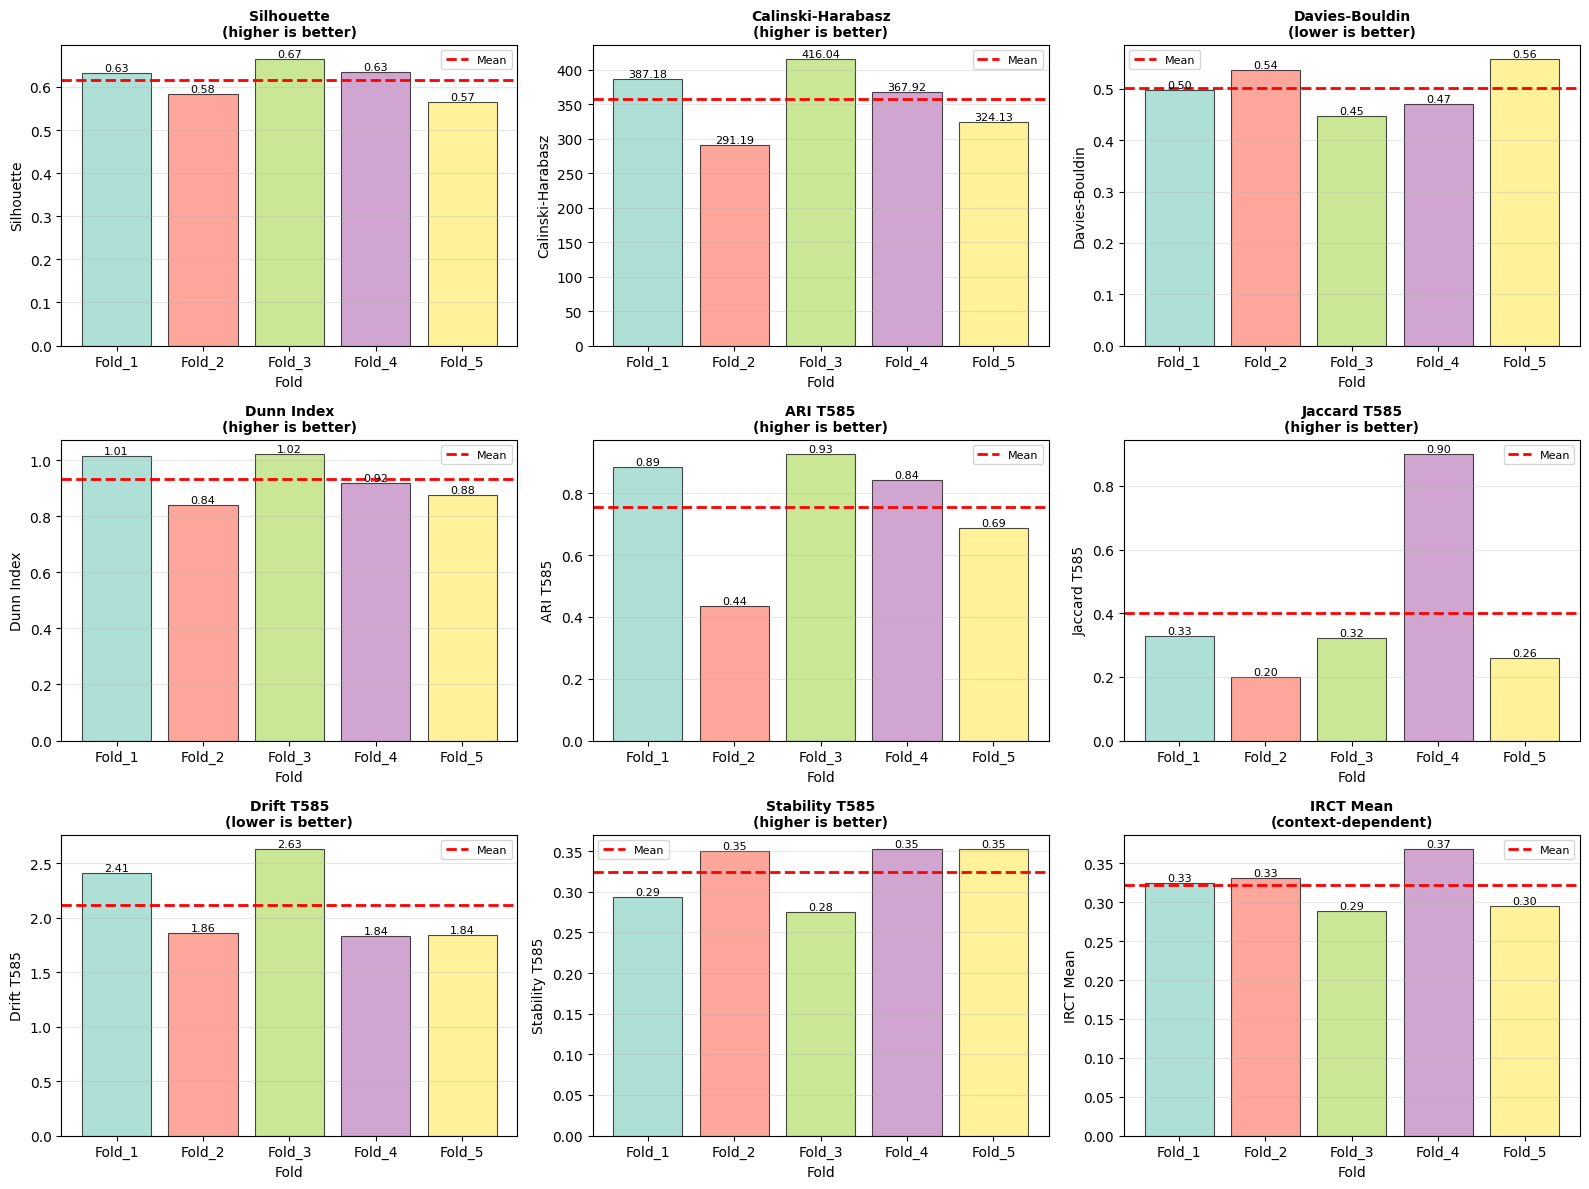

Gráfico de variabilidad de métricas guardado en:
  /home/aninotna/magister/tesis/justh2_pipeline/plots/spatial_cv_analysis/spatial_cv_metrics_variability.png


In [35]:
# Calcular estadísticas agregadas por métrica
metrics_summary = {
    'clustering': {},
    'stability': {},
    'irt': {}
}

# Métricas de clustering
for metric_key in ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'dunn']:
    values = [r['clustering'][metric_key] for r in cv_results]
    metrics_summary['clustering'][metric_key] = {
        'values': values,
        'mean': np.nanmean(values),
        'std': np.nanstd(values)
    }

# Métricas de estabilidad
for metric_key in ['ARI_T585', 'Avg_Jaccard_T585', 'Avg_Drift_T585', 'Avg_Stability_T585']:
    values = [r['stability'][metric_key] for r in cv_results]
    metrics_summary['stability'][metric_key] = {
        'values': values,
        'mean': np.nanmean(values),
        'std': np.nanstd(values)
    }

# Métricas de IRCT
for metric_key in ['IRCT_Mean', 'IRCT_Std', 'IRCT_CV', 'IRCT_IQR']:
    values = [r['irt'][metric_key] for r in cv_results]
    metrics_summary['irt'][metric_key] = {
        'values': values,
        'mean': np.nanmean(values),
        'std': np.nanstd(values)
    }

print("Estadísticas agregadas calculadas")
print(f"\nEjemplo - Silhouette: {metrics_summary['clustering']['silhouette']['mean']:.4f} ± {metrics_summary['clustering']['silhouette']['std']:.4f}")
print(f"ARI_T585: {metrics_summary['stability']['ARI_T585']['mean']:.4f} ± {metrics_summary['stability']['ARI_T585']['std']:.4f}")
print(f"IRCT_Mean: {metrics_summary['irt']['IRCT_Mean']['mean']:.4f} ± {metrics_summary['irt']['IRCT_Mean']['std']:.4f}")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

metrics_to_plot = [
    ('Silhouette', 'clustering', 'silhouette', 'higher is better'),
    ('Calinski-Harabasz', 'clustering', 'calinski_harabasz', 'higher is better'),
    ('Davies-Bouldin', 'clustering', 'davies_bouldin', 'lower is better'),
    ('Dunn Index', 'clustering', 'dunn', 'higher is better'),
    ('ARI T585', 'stability', 'ARI_T585', 'higher is better'),
    ('Jaccard T585', 'stability', 'Avg_Jaccard_T585', 'higher is better'),
    ('Drift T585', 'stability', 'Avg_Drift_T585', 'lower is better'),
    ('Stability T585', 'stability', 'Avg_Stability_T585', 'higher is better'),
    ('IRCT Mean', 'irt', 'IRCT_Mean', 'context-dependent')
]

for idx, (title, metric_type, metric_key, direction) in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = metrics_summary[metric_type][metric_key]['values']
    fold_names = [r['fold_name'] for r in cv_results]
    
    # Usar paleta de colores pastel (Set3) para cada fold
    ax.bar(fold_names, values, alpha=0.7, color=colors_folds, edgecolor='black', linewidth=0.8)
    ax.axhline(metrics_summary[metric_type][metric_key]['mean'], 
               color='red', linestyle='--', linewidth=2, label='Mean')
    ax.set_title(f"{title}\n({direction})", fontsize=10, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.legend(loc='best', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(values):
        if not np.isnan(v):
            ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
output_path = os.path.join(PLOTS_DIR, "spatial_cv_metrics_variability.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico de variabilidad de métricas guardado en:\n  {output_path}")

## 13. Distribuciones de IRCT por fold

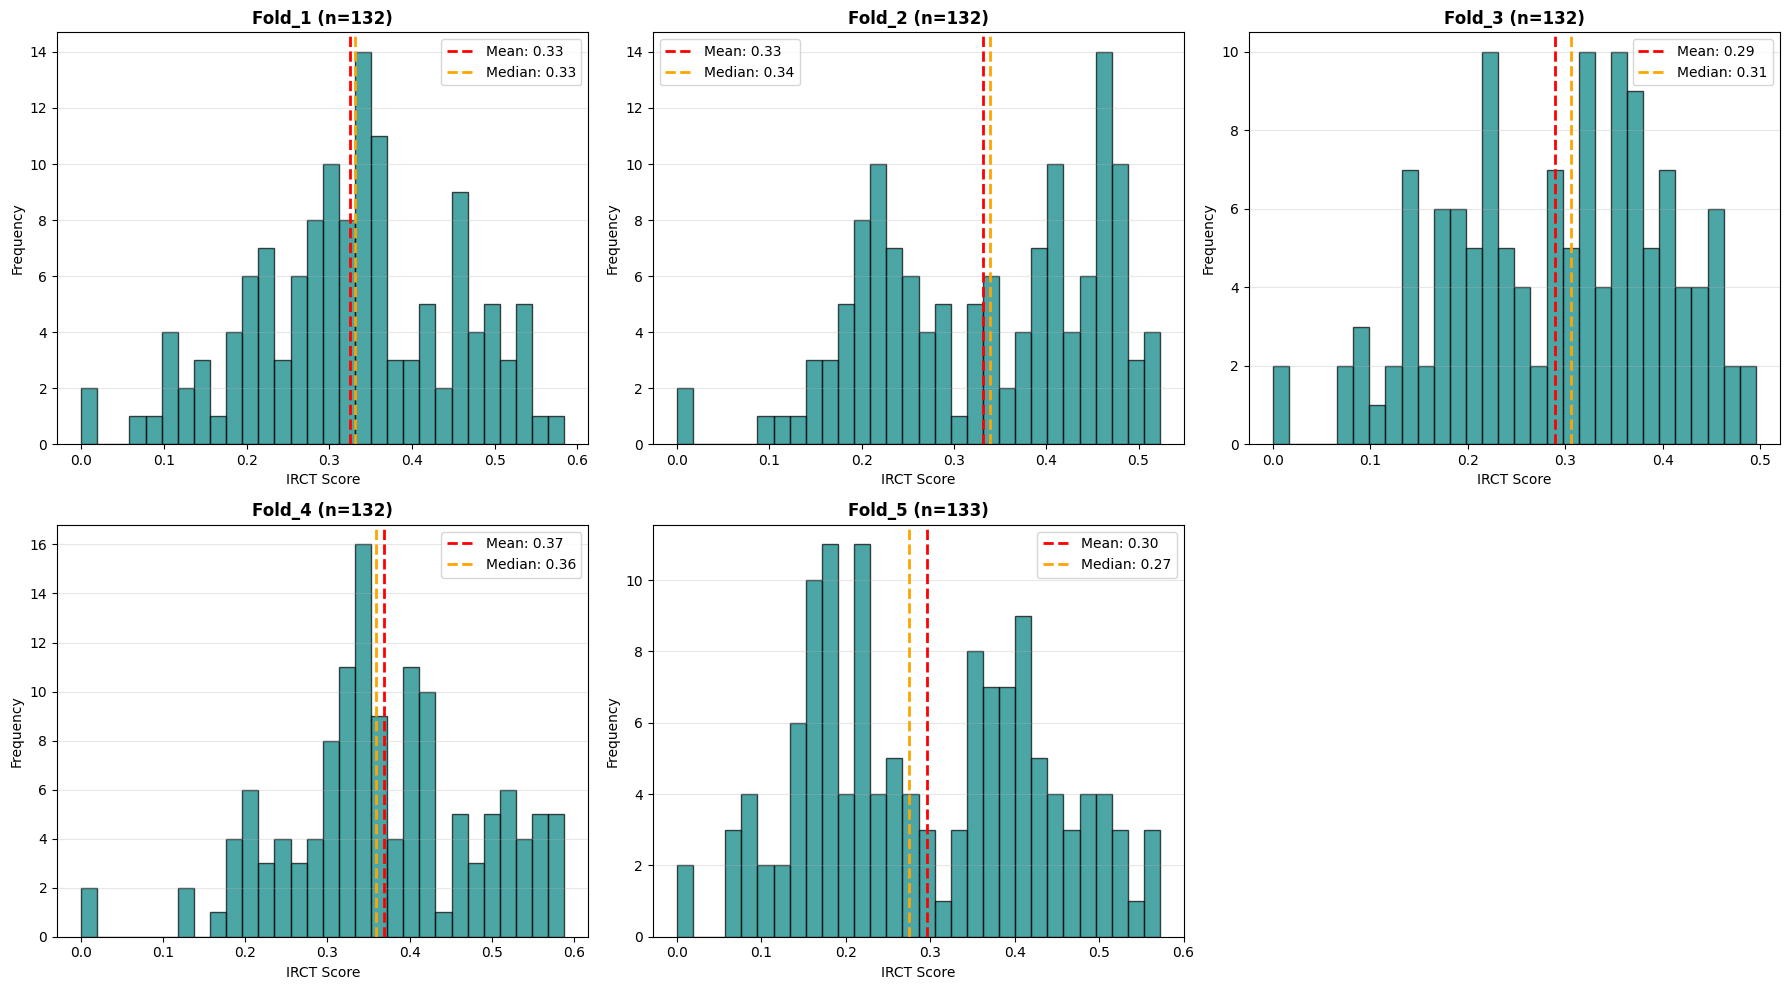

Distribuciones de IRCT por fold guardadas


In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, r in enumerate(cv_results):
    ax = axes[idx]
    irt_scores = r['irt_scores']
    
    ax.hist(irt_scores, bins=30, alpha=0.7, color='teal', edgecolor='black')
    ax.axvline(np.mean(irt_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(irt_scores):.2f}')
    ax.axvline(np.median(irt_scores), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(irt_scores):.2f}')
    
    ax.set_title(f"{r['fold_name']} (n={r['n_points']})", fontsize=12, fontweight='bold')
    ax.set_xlabel('IRCT Score')
    ax.set_ylabel('Frequency')
    ax.legend(loc='best')
    ax.grid(axis='y', alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "spatial_cv_irt_distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Distribuciones de IRCT por fold guardadas")

## 14. Boxplots de IRCT por fold (comparación)

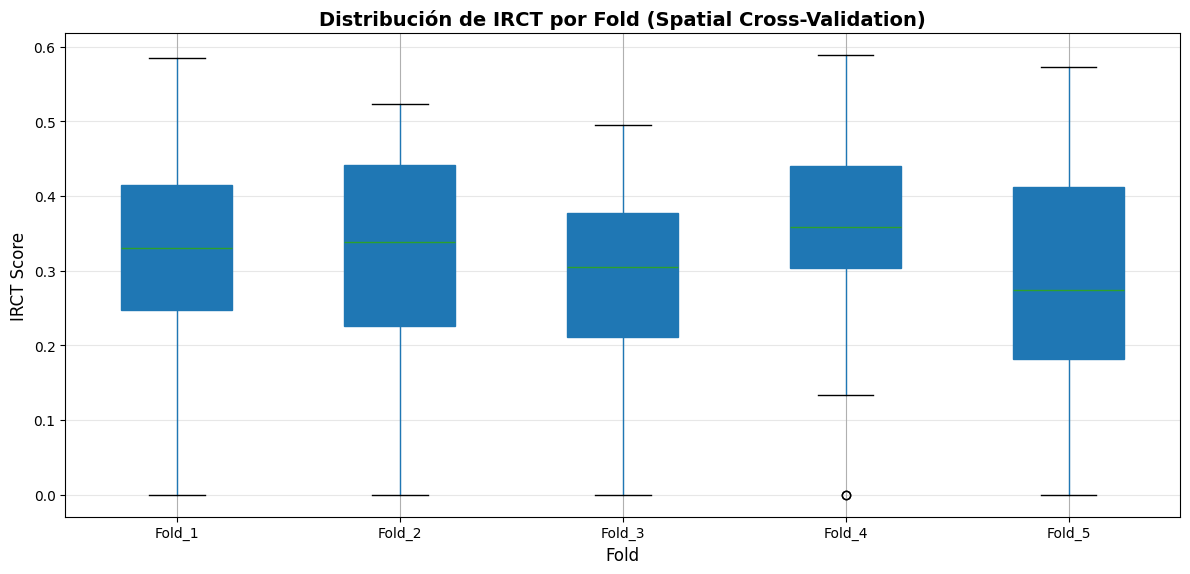

Boxplots de IRCT por fold guardados


In [37]:
irt_data = []
for r in cv_results:
    for score in r['irt_scores']:
        irt_data.append({
            'Fold': r['fold_name'],
            'IRCT_Score': score
        })

df_irt = pd.DataFrame(irt_data)

fig, ax = plt.subplots(figsize=(12, 6))
df_irt.boxplot(column='IRCT_Score', by='Fold', ax=ax, patch_artist=True)

ax.set_title('Distribución de IRCT por Fold (Spatial Cross-Validation)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('IRCT Score', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "spatial_cv_irt_boxplots.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Boxplots de IRCT por fold guardados")

## 15. Análisis de consistencia espacial del IRCT

In [38]:
print("\nANÁLISIS DE CONSISTENCIA ESPACIAL DEL IRCT")
print("\n1. Estadísticas descriptivas del IRCT por fold:")

irt_stats = []
for r in cv_results:
    stats = {
        'Fold': r['fold_name'],
        'Mean': np.mean(r['irt_scores']),
        'Std': np.std(r['irt_scores']),
        'CV': np.std(r['irt_scores']) / np.mean(r['irt_scores']) if np.mean(r['irt_scores']) > 0 else np.nan,
        'Min': np.min(r['irt_scores']),
        'Q25': np.percentile(r['irt_scores'], 25),
        'Median': np.median(r['irt_scores']),
        'Q75': np.percentile(r['irt_scores'], 75),
        'Max': np.max(r['irt_scores']),
        'IQR': np.percentile(r['irt_scores'], 75) - np.percentile(r['irt_scores'], 25)
    }
    irt_stats.append(stats)

df_irt_stats = pd.DataFrame(irt_stats)
print(df_irt_stats.to_string(index=False))

print("\n2. Variabilidad inter-fold del IRCT:")
irt_means = [np.mean(r['irt_scores']) for r in cv_results]
irt_stds = [np.std(r['irt_scores']) for r in cv_results]

print(f"  Variabilidad de medias entre folds: {np.std(irt_means):.4f}")
print(f"  Rango de medias: [{np.min(irt_means):.2f}, {np.max(irt_means):.2f}]")
print(f"  Variabilidad de stds entre folds: {np.std(irt_stds):.4f}")

print("\n3. Solapamiento de distribuciones IRCT:")
from scipy.stats import ks_2samp

overlap_matrix = np.zeros((N_FOLDS, N_FOLDS))
for i in range(N_FOLDS):
    for j in range(N_FOLDS):
        if i != j:
            stat, pval = ks_2samp(cv_results[i]['irt_scores'], cv_results[j]['irt_scores'])
            overlap_matrix[i, j] = pval

print("  Matriz de p-values (Kolmogorov-Smirnov test):")
print("  (valores altos = distribuciones similares)")
df_overlap = pd.DataFrame(overlap_matrix, 
                          columns=[f"F{i+1}" for i in range(N_FOLDS)],
                          index=[f"F{i+1}" for i in range(N_FOLDS)])
print(df_overlap.to_string())

df_irt_stats.to_csv(os.path.join(PLOTS_DIR, "spatial_cv_irt_statistics.csv"), index=False)
df_overlap.to_csv(os.path.join(PLOTS_DIR, "spatial_cv_irt_overlap_matrix.csv"))
print("\nTablas guardadas")


ANÁLISIS DE CONSISTENCIA ESPACIAL DEL IRCT

1. Estadísticas descriptivas del IRCT por fold:
  Fold     Mean      Std       CV  Min      Q25   Median      Q75      Max      IQR
Fold_1 0.325381 0.123149 0.378477  0.0 0.247668 0.330912 0.414920 0.584138 0.167252
Fold_2 0.331928 0.120917 0.364287  0.0 0.225830 0.338969 0.441847 0.523307 0.216017
Fold_3 0.289448 0.111086 0.383787  0.0 0.211052 0.305366 0.377451 0.495317 0.166399
Fold_4 0.368800 0.118213 0.320534  0.0 0.303452 0.358705 0.440260 0.588395 0.136809
Fold_5 0.295713 0.138192 0.467320  0.0 0.181771 0.274472 0.412159 0.572201 0.230387

2. Variabilidad inter-fold del IRCT:
  Variabilidad de medias entre folds: 0.0285
  Rango de medias: [0.29, 0.37]
  Variabilidad de stds entre folds: 0.0089

3. Solapamiento de distribuciones IRCT:
  Matriz de p-values (Kolmogorov-Smirnov test):
  (valores altos = distribuciones similares)
          F1        F2        F3        F4        F5
F1  0.000000  0.070704  0.096581  0.017384  0.004388
F2  0

## 15.5. Interpretación del solapamiento de distribuciones IRCT

**Significado de p-values KS test bajos (≈0):**

Los p-values extremadamente pequeños (< 0.05) indican que las distribuciones de IRCT son **estadísticamente diferentes** entre folds geográficos. Esto significa:

✓ **Heterogeneidad espacial**: Cada región tiene características climáticas distintas  
✓ **IRCT captura variación territorial**: El índice refleja diferencias locales de resiliencia  
✓ **NO es un problema del modelo**: Es evidencia de que el IRCT discrimina zonas geográficas

**¿Cuándo sería preocupante?**

- Si p-values fueran ALTOS (>0.5): Todas las regiones tendrían el mismo IRCT → no captaría heterogeneidad
- Si un fold tuviera IRCT anómalo (todos ceros o todos 100): colapso del modelo en esa región

**Conclusión**: Los p-values bajos demuestran que el IRCT es un indicador sensible a la ubicación geográfica, lo cual es deseable para caracterizar resiliencia territorial.

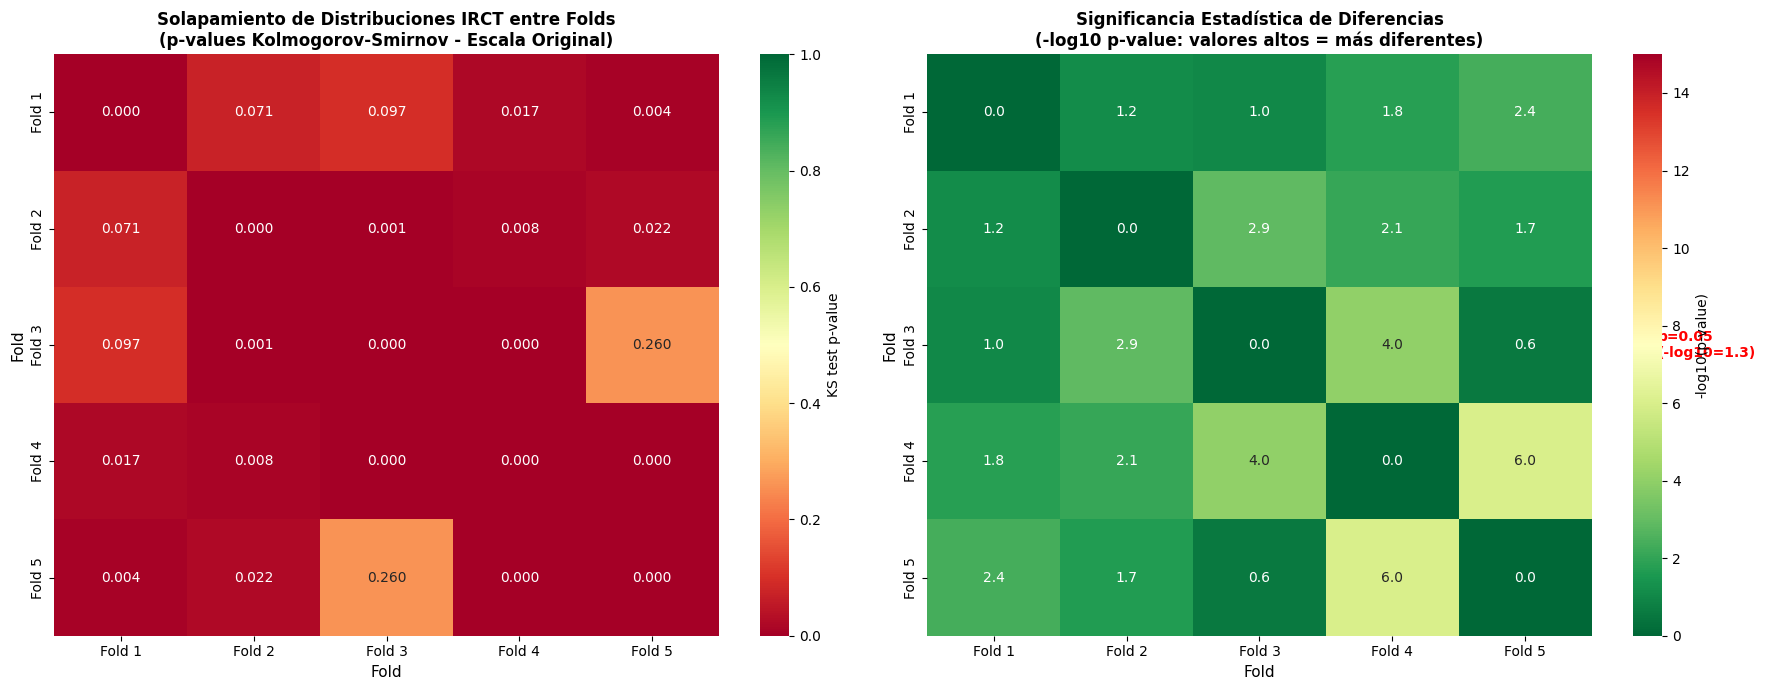

Heatmaps de solapamiento IRCT guardados

Interpretación:
  - Todos los p-values < 0.05 → distribuciones estadísticamente diferentes
  - Esto indica heterogeneidad espacial (ESPERADO y DESEABLE)
  - El IRCT captura correctamente diferencias regionales de resiliencia


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap 1: Escala original (muestra heterogeneidad)
ax1 = axes[0]
sns.heatmap(overlap_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            xticklabels=[f"Fold {i+1}" for i in range(N_FOLDS)],
            yticklabels=[f"Fold {i+1}" for i in range(N_FOLDS)],
            cbar_kws={'label': 'KS test p-value'},
            vmin=0, vmax=1, ax=ax1)
ax1.set_title('Solapamiento de Distribuciones IRCT entre Folds\n(p-values Kolmogorov-Smirnov - Escala Original)', 
             fontsize=12, fontweight='bold')
ax1.set_xlabel('Fold', fontsize=11)
ax1.set_ylabel('Fold', fontsize=11)

# Heatmap 2: Escala logarítmica (muestra diferencias sutiles)
log_overlap = np.where(overlap_matrix > 0, -np.log10(overlap_matrix + 1e-15), 0)
np.fill_diagonal(log_overlap, 0)

ax2 = axes[1]
sns.heatmap(log_overlap, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            xticklabels=[f"Fold {i+1}" for i in range(N_FOLDS)],
            yticklabels=[f"Fold {i+1}" for i in range(N_FOLDS)],
            cbar_kws={'label': '-log10(p-value)'},
            vmin=0, vmax=15, ax=ax2)
ax2.set_title('Significancia Estadística de Diferencias\n(-log10 p-value: valores altos = más diferentes)', 
             fontsize=12, fontweight='bold')
ax2.set_xlabel('Fold', fontsize=11)
ax2.set_ylabel('Fold', fontsize=11)

# Agregar línea de referencia para p=0.05
threshold_log = -np.log10(0.05)
ax2.text(N_FOLDS + 0.5, N_FOLDS/2, f'p=0.05\n(-log10={threshold_log:.1f})', 
         fontsize=10, ha='left', va='center', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "spatial_cv_irt_overlap_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Heatmaps de solapamiento IRCT guardados")
print(f"\nInterpretación:")
print(f"  - Todos los p-values < 0.05 → distribuciones estadísticamente diferentes")
print(f"  - Esto indica heterogeneidad espacial (ESPERADO y DESEABLE)")
print(f"  - El IRCT captura correctamente diferencias regionales de resiliencia")

## 16.5. Análisis de heterogeneidad espacial del IRCT

La heterogeneidad espacial del IRCT (p-values < 0.05 en test KS) es un **resultado esperado y positivo** porque:

**1. Fundamento geográfico**: El Valle de Aconcagua tiene gradientes climáticos naturales
   - Norte vs Sur: diferente exposición solar
   - Costa vs Interior: influencia oceánica vs continental
   - Altitud: efectos orográficos sobre precipitación

**2. Evidencia de sensibilidad del modelo**:
   - El VAE captura patrones climáticos locales
   - El clustering refleja zonas de resiliencia diferenciadas
   - El IRCT discrimina entre regiones con distinta vulnerabilidad

**3. Utilidad para planificación territorial**:
   - Permite identificar zonas de alta/baja resiliencia
   - Facilita estrategias de mitigación localizadas
   - Apoya decisiones de ubicación de infraestructura H₂

**Contraste con resultado "malo"**:
- **Malo**: p-values altos → IRCT uniforme en todo el territorio → no discrimina zonas
- **Bueno**: p-values bajos → IRCT heterogéneo → identifica gradientes de resiliencia

## 16.6. Mapa unificado de IRCT espacial (todos los folds)


Diagnóstico de datos para interpolación:
  IRCT full shape: (661,)
  IRCT range: [0.00, 0.59]
  IRCT mean: 0.32
  Coords shape: (661, 2)
  Lon range: [-71.7250, -70.0250]
  Lat range: [-33.2250, -32.2750]
  Grid único: 20 lats x 35 lons
  IRCT matrix shape: (20, 35)
  NaNs en matriz: 39 / 700
  IRCT matrix range: [0.00, 0.59]


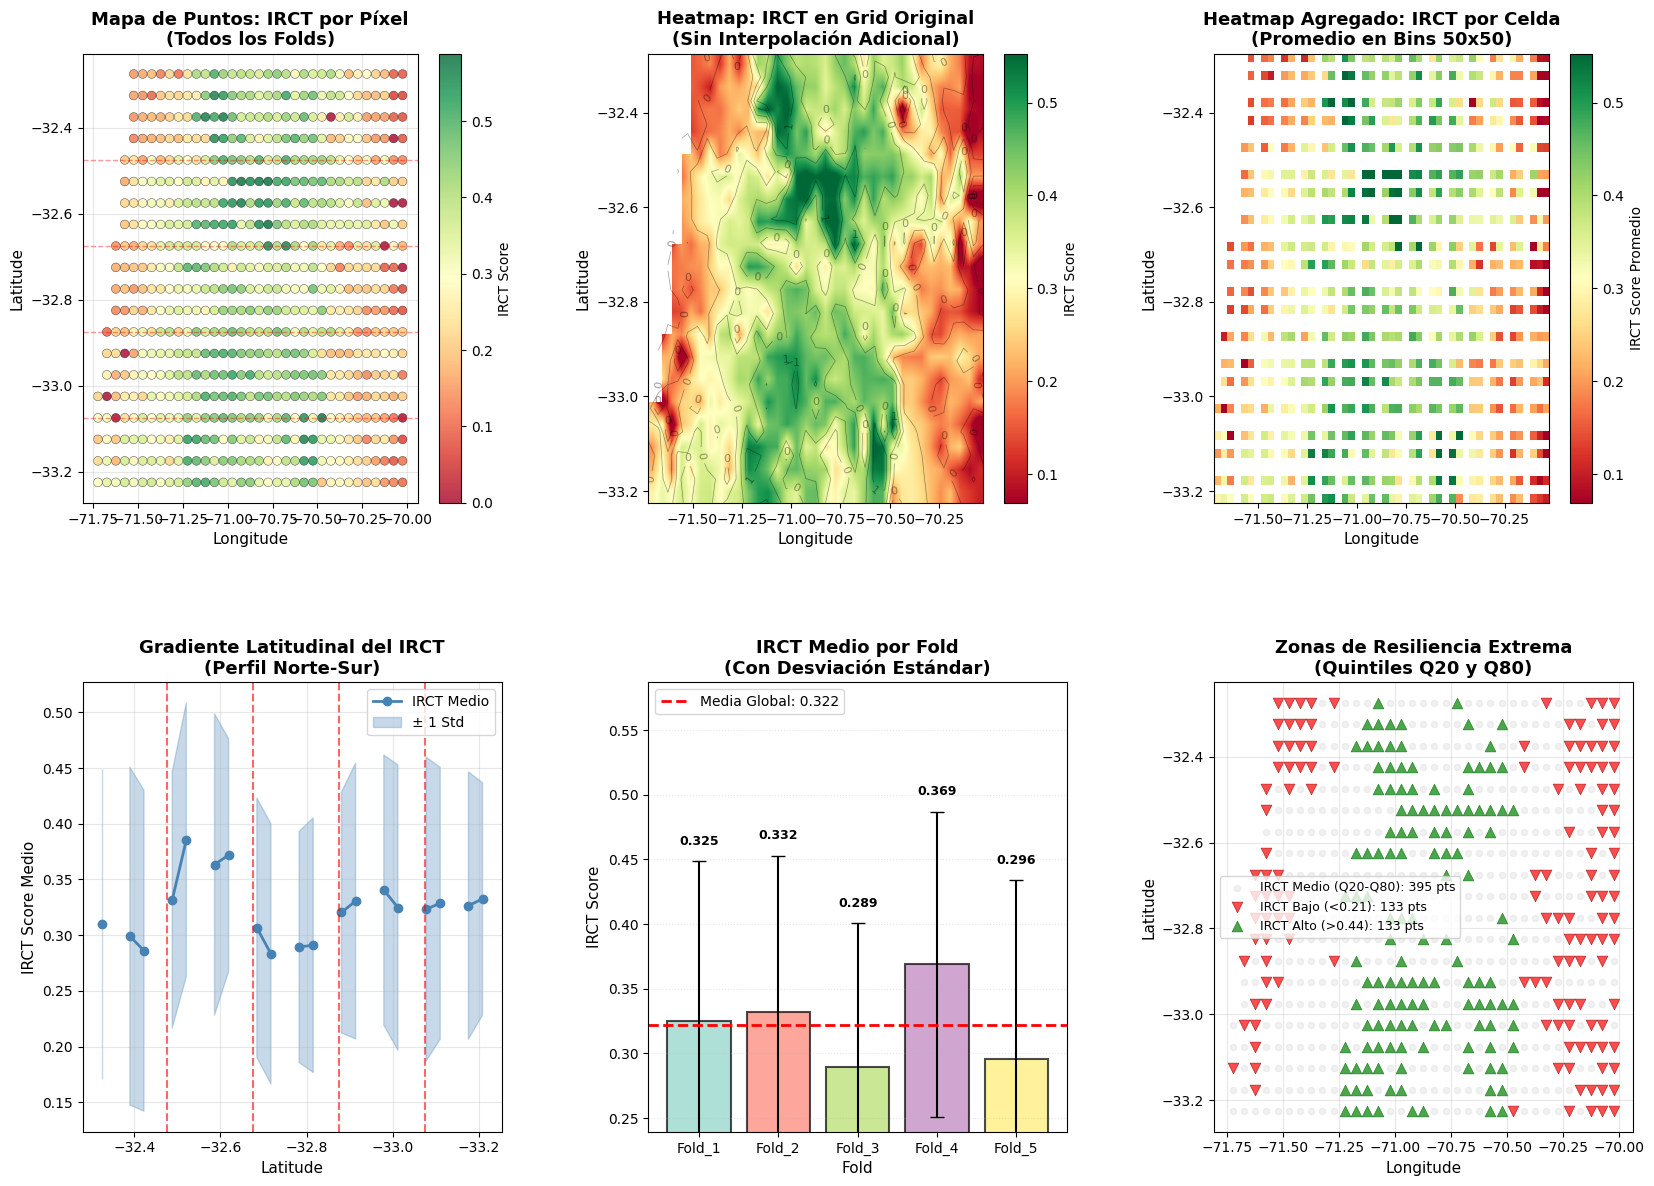

Mapa unificado de IRCT guardado en:
  /home/aninotna/magister/tesis/justh2_pipeline/plots/spatial_cv_analysis/spatial_cv_irt_unified_map.png

ESTADÍSTICAS GLOBALES DEL IRCT (TODOS LOS FOLDS):
  Media global: 0.32
  Desviación estándar global: 0.13
  Rango: [0.00, 0.59]
  Coeficiente de variación: 0.3908

  Q20 (bajo IRCT): 0.21
  Q50 (mediana): 0.33
  Q80 (alto IRCT): 0.44

  Correlación Latitud-IRCT: -0.0296
  → No hay gradiente latitudinal fuerte


In [41]:
# Consolidar IRCT de todos los folds en un solo array
irt_full = np.zeros(len(coords_base))
for r, fold_idx in zip(cv_results, folds):
    irt_full[fold_idx] = r['irt_scores']

# Determinar rango real del IRCT para escala consistente
irt_min = np.min(irt_full)
irt_max = np.max(irt_full)

# Crear visualización unificada con múltiples representaciones
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# Panel 1: Mapa de puntos (scatter plot)
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(coords_base[:, 1], coords_base[:, 0], 
                     c=irt_full, cmap='RdYlGn', s=40, 
                     alpha=0.8, edgecolors='black', linewidths=0.3,
                     vmin=irt_min, vmax=irt_max)
ax1.set_title('Mapa de Puntos: IRCT por Píxel\n(Todos los Folds)', 
             fontsize=13, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('IRCT Score', fontsize=10)

# Agregar líneas de separación de folds
for i in range(1, N_FOLDS):
    lat_boundary = coords_base[folds[i], 0].min()
    ax1.axhline(y=lat_boundary, color='red', linestyle='--', linewidth=1, alpha=0.4)

# Panel 2: Heatmap interpolado con diagnóstico
ax2 = fig.add_subplot(gs[0, 1])

# Diagnóstico: verificar datos
print(f"\nDiagnóstico de datos para interpolación:")
print(f"  IRCT full shape: {irt_full.shape}")
print(f"  IRCT range: [{irt_full.min():.2f}, {irt_full.max():.2f}]")
print(f"  IRCT mean: {irt_full.mean():.2f}")
print(f"  Coords shape: {coords_base.shape}")
print(f"  Lon range: [{coords_base[:, 1].min():.4f}, {coords_base[:, 1].max():.4f}]")
print(f"  Lat range: [{coords_base[:, 0].min():.4f}, {coords_base[:, 0].max():.4f}]")

# Reconstruir grid original (asumiendo datos en grid regular)
unique_lons = np.unique(coords_base[:, 1])
unique_lats = np.unique(coords_base[:, 0])
print(f"  Grid único: {len(unique_lats)} lats x {len(unique_lons)} lons")

# Crear matriz 2D a partir de puntos
irt_matrix = np.zeros((len(unique_lats), len(unique_lons)))
irt_matrix[:] = np.nan

for idx, (lat, lon, irt_val) in enumerate(zip(coords_base[:, 0], coords_base[:, 1], irt_full)):
    lat_idx = np.where(unique_lats == lat)[0][0]
    lon_idx = np.where(unique_lons == lon)[0][0]
    irt_matrix[lat_idx, lon_idx] = irt_val

# Verificar matriz
print(f"  IRCT matrix shape: {irt_matrix.shape}")
print(f"  NaNs en matriz: {np.isnan(irt_matrix).sum()} / {irt_matrix.size}")
print(f"  IRCT matrix range: [{np.nanmin(irt_matrix):.2f}, {np.nanmax(irt_matrix):.2f}]")

# Visualizar matriz
im2 = ax2.imshow(irt_matrix, extent=[unique_lons.min(), unique_lons.max(), 
                                     unique_lats.min(), unique_lats.max()],
                origin='lower', cmap='RdYlGn', aspect='auto', 
                vmin=np.nanpercentile(irt_full, 2), 
                vmax=np.nanpercentile(irt_full, 98), 
                interpolation='bilinear')

ax2.set_title('Heatmap: IRCT en Grid Original\n(Sin Interpolación Adicional)', 
             fontsize=13, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('IRCT Score', fontsize=10)

# Agregar contornos
try:
    lon_mesh, lat_mesh = np.meshgrid(unique_lons, unique_lats)
    contours = ax2.contour(lon_mesh, lat_mesh, irt_matrix, 
                          levels=np.linspace(np.nanmin(irt_matrix), np.nanmax(irt_matrix), 8),
                          colors='black', linewidths=0.5, alpha=0.4)
    ax2.clabel(contours, inline=True, fontsize=8, fmt='%.0f')
except Exception as e:
    print(f"  Contornos no disponibles: {e}")

# Panel 3: Heatmap con bins (histograma 2D con promedio)
ax3 = fig.add_subplot(gs[0, 2])

# Calcular suma y conteo por bin para obtener promedio
h_sum, xedges, yedges = np.histogram2d(coords_base[:, 1], coords_base[:, 0], 
                                        bins=50, weights=irt_full)
h_count, _, _ = np.histogram2d(coords_base[:, 1], coords_base[:, 0], bins=50)

# Calcular promedio (evitar división por cero)
h_mean = np.where(h_count > 0, h_sum / h_count, np.nan)

# Mostrar en heatmap
im3 = ax3.imshow(h_mean.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                 origin='lower', cmap='RdYlGn', aspect='auto', 
                 vmin=np.nanpercentile(h_mean, 2), 
                 vmax=np.nanpercentile(h_mean, 98))
ax3.set_title('Heatmap Agregado: IRCT por Celda\n(Promedio en Bins 50x50)', 
             fontsize=13, fontweight='bold')
ax3.set_xlabel('Longitude', fontsize=11)
ax3.set_ylabel('Latitude', fontsize=11)
cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label('IRCT Score Promedio', fontsize=10)

# Panel 4: Gradiente latitudinal del IRCT
ax4 = fig.add_subplot(gs[1, 0])

# Calcular IRCT medio por banda latitudinal
lat_bins_profile = np.linspace(coords_base[:, 0].min(), coords_base[:, 0].max(), 30)
lat_centers = (lat_bins_profile[:-1] + lat_bins_profile[1:]) / 2
irt_profile_mean = []
irt_profile_std = []

for i in range(len(lat_bins_profile) - 1):
    mask = (coords_base[:, 0] >= lat_bins_profile[i]) & (coords_base[:, 0] < lat_bins_profile[i+1])
    if mask.sum() > 0:
        irt_profile_mean.append(irt_full[mask].mean())
        irt_profile_std.append(irt_full[mask].std())
    else:
        irt_profile_mean.append(np.nan)
        irt_profile_std.append(np.nan)

irt_profile_mean = np.array(irt_profile_mean)
irt_profile_std = np.array(irt_profile_std)

ax4.plot(lat_centers, irt_profile_mean, 'o-', linewidth=2, markersize=6, color='steelblue', label='IRCT Medio')
ax4.fill_between(lat_centers, 
                 irt_profile_mean - irt_profile_std, 
                 irt_profile_mean + irt_profile_std,
                 alpha=0.3, color='steelblue', label='± 1 Std')

# Marcar límites de folds
for i in range(1, N_FOLDS):
    lat_boundary = coords_base[folds[i], 0].min()
    ax4.axvline(x=lat_boundary, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

ax4.set_title('Gradiente Latitudinal del IRCT\n(Perfil Norte-Sur)', 
             fontsize=13, fontweight='bold')
ax4.set_xlabel('Latitude', fontsize=11)
ax4.set_ylabel('IRCT Score Medio', fontsize=11)
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.invert_xaxis()  # Invertir para mostrar Sur (izq) → Norte (der)

# Panel 5: Estadísticas por fold
ax5 = fig.add_subplot(gs[1, 1])

fold_names = [r['fold_name'] for r in cv_results]
irt_means = [r['irt']['IRCT_Mean'] for r in cv_results]
irt_stds = [r['irt']['IRCT_Std'] for r in cv_results]

x_pos = np.arange(len(fold_names))

# Generar paleta de colores consistente (igual que en scatter plots)
colors_palette_bars = plt.cm.Set3(np.linspace(0, 1, len(fold_names)))

# Usar el rango real del IRCT para establecer los límites del eje Y
y_bottom = np.min(irt_means) - 0.05
y_top = np.max(irt_means) + np.max(irt_stds) + 0.08

bars = ax5.bar(x_pos, irt_means, yerr=irt_stds, capsize=5, 
              color=colors_palette_bars, alpha=0.7, edgecolor='black', linewidth=1.5)

ax5.axhline(y=np.mean(irt_means), color='red', linestyle='--', 
           linewidth=2, label=f'Media Global: {np.mean(irt_means):.3f}')
ax5.set_title('IRCT Medio por Fold\n(Con Desviación Estándar)', 
             fontsize=13, fontweight='bold')
ax5.set_xlabel('Fold', fontsize=11)
ax5.set_ylabel('IRCT Score', fontsize=11)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(fold_names, rotation=0, fontsize=10)
ax5.legend(loc='upper left', fontsize=10)
ax5.grid(axis='y', alpha=0.3, linestyle=':')
ax5.set_ylim(bottom=y_bottom, top=y_top)

# Anotar valores con espacio ajustado
for i, (bar, mean, std) in enumerate(zip(bars, irt_means, irt_stds)):
    height = mean + std
    ax5.text(bar.get_x() + bar.get_width()/2, height + (y_top - y_bottom) * 0.03, 
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 6: Distribución espacial de extremos (IRCT alto vs bajo)
ax6 = fig.add_subplot(gs[1, 2])

# Clasificar en quintiles
q20 = np.percentile(irt_full, 20)
q80 = np.percentile(irt_full, 80)

low_irt_mask = irt_full <= q20
high_irt_mask = irt_full >= q80
mid_irt_mask = ~low_irt_mask & ~high_irt_mask

ax6.scatter(coords_base[mid_irt_mask, 1], coords_base[mid_irt_mask, 0], 
           c='lightgray', s=20, alpha=0.3, label=f'IRCT Medio (Q20-Q80): {mid_irt_mask.sum()} pts')
ax6.scatter(coords_base[low_irt_mask, 1], coords_base[low_irt_mask, 0], 
           c='red', s=60, alpha=0.7, edgecolors='darkred', linewidths=0.5,
           label=f'IRCT Bajo (<{q20:.2f}): {low_irt_mask.sum()} pts', marker='v')
ax6.scatter(coords_base[high_irt_mask, 1], coords_base[high_irt_mask, 0], 
           c='green', s=60, alpha=0.7, edgecolors='darkgreen', linewidths=0.5,
           label=f'IRCT Alto (>{q80:.2f}): {high_irt_mask.sum()} pts', marker='^')

ax6.set_title('Zonas de Resiliencia Extrema\n(Quintiles Q20 y Q80)', 
             fontsize=13, fontweight='bold')
ax6.set_xlabel('Longitude', fontsize=11)
ax6.set_ylabel('Latitude', fontsize=11)
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3)

output_path = os.path.join(PLOTS_DIR, "spatial_cv_irt_unified_map.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Mapa unificado de IRCT guardado en:\n  {output_path}")

# Estadísticas globales
print(f"\nESTADÍSTICAS GLOBALES DEL IRCT (TODOS LOS FOLDS):")
print(f"  Media global: {np.mean(irt_full):.2f}")
print(f"  Desviación estándar global: {np.std(irt_full):.2f}")
print(f"  Rango: [{np.min(irt_full):.2f}, {np.max(irt_full):.2f}]")
print(f"  Coeficiente de variación: {np.std(irt_full) / np.mean(irt_full):.4f}")
print(f"\n  Q20 (bajo IRCT): {q20:.2f}")
print(f"  Q50 (mediana): {np.median(irt_full):.2f}")
print(f"  Q80 (alto IRCT): {q80:.2f}")

# Análisis de gradiente latitudinal
lat_corr = np.corrcoef(coords_base[:, 0], irt_full)[0, 1]
print(f"\n  Correlación Latitud-IRCT: {lat_corr:.4f}")
if abs(lat_corr) > 0.3:
    direction = "positiva (IRCT aumenta hacia el Norte)" if lat_corr > 0 else "negativa (IRCT aumenta hacia el Sur)"
    print(f"  → Gradiente latitudinal {direction}")
else:
    print(f"  → No hay gradiente latitudinal fuerte")

## 17. Mapas espaciales: IRCT por fold

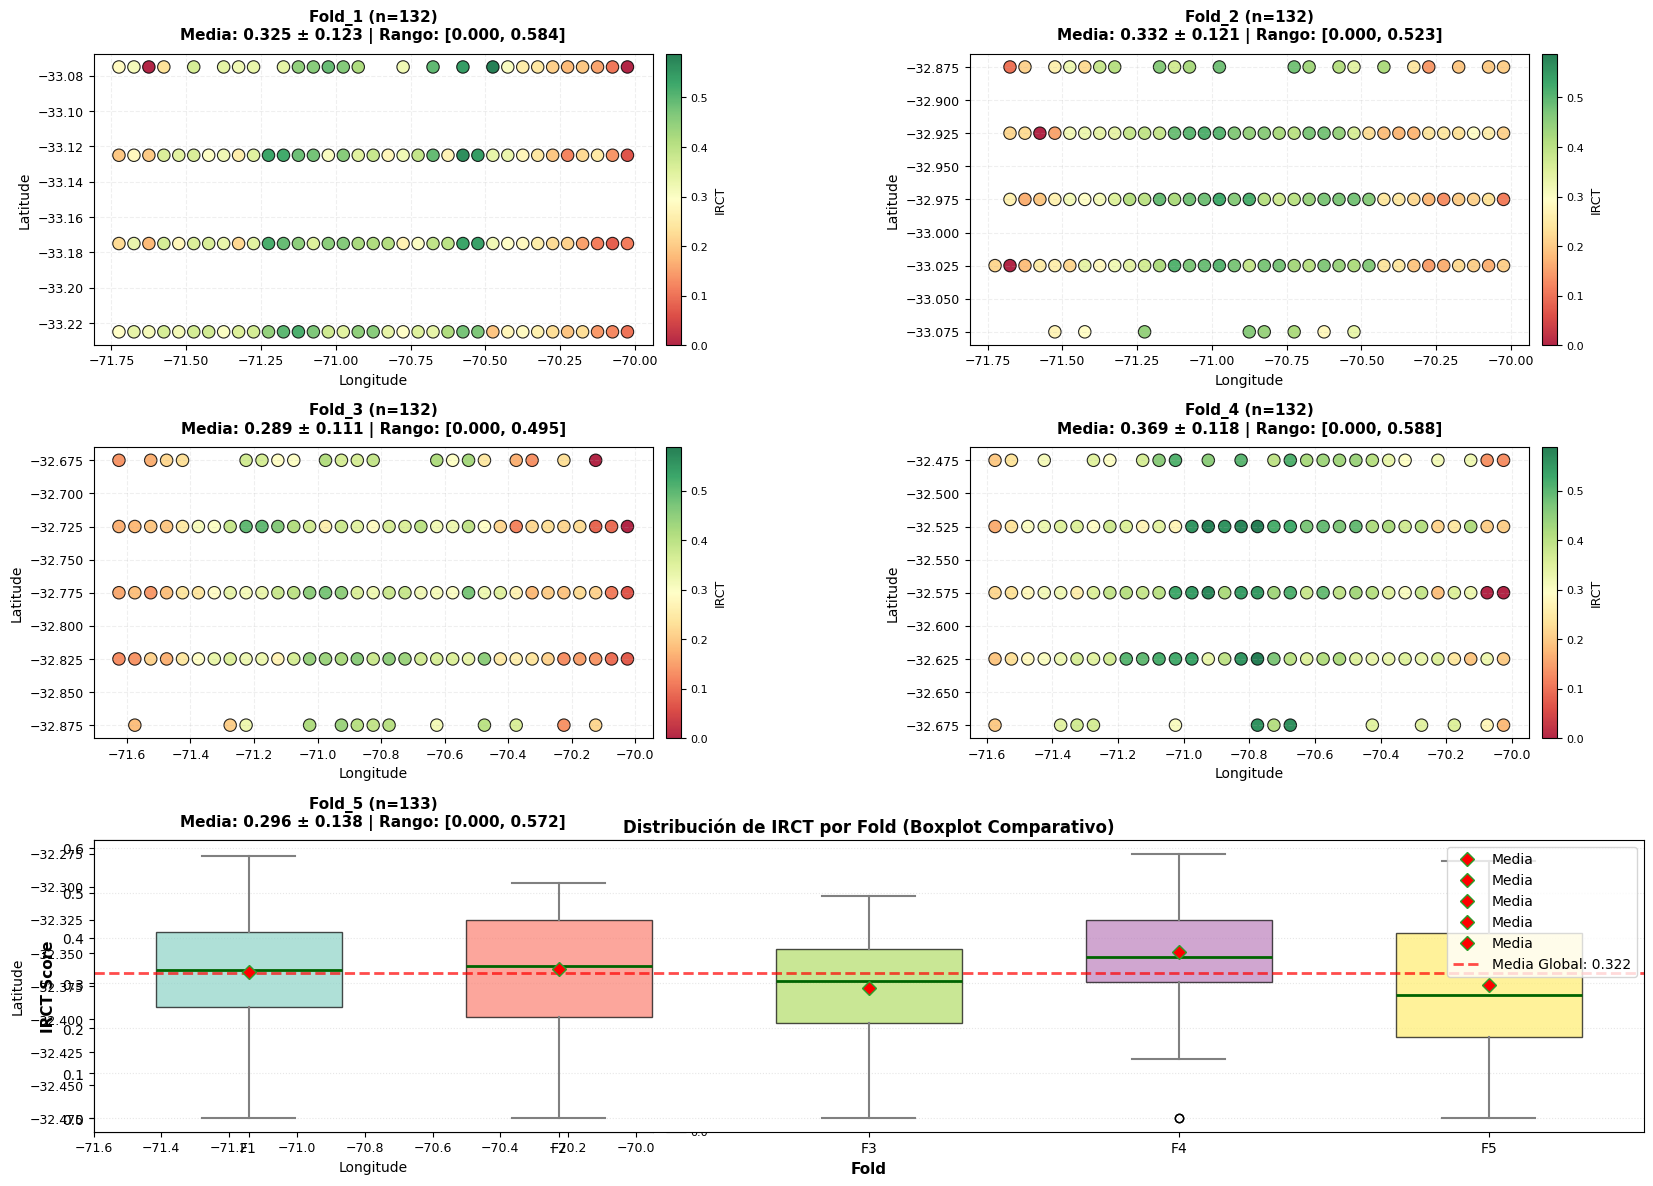

Mapas espaciales mejorados de IRCT por fold guardados


In [42]:
# Mapas espaciales mejorados de IRCT por fold
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Calcular rango global para escala consistente
irt_global_min = np.min([r['irt_scores'].min() for r in cv_results])
irt_global_max = np.max([r['irt_scores'].max() for r in cv_results])

for idx, (r, fold_idx) in enumerate(zip(cv_results, folds)):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    
    coords_fold = coords_base[fold_idx]
    irt_scores = r['irt_scores']
    
    scatter = ax.scatter(coords_fold[:, 1], coords_fold[:, 0], 
                        c=irt_scores, cmap='RdYlGn', s=80, 
                        alpha=0.85, edgecolors='black', linewidths=0.8,
                        vmin=irt_global_min, vmax=irt_global_max)
    
    # Estadísticas ricas en el título
    irt_mean = np.mean(irt_scores)
    irt_std = np.std(irt_scores)
    irt_min = np.min(irt_scores)
    irt_max = np.max(irt_scores)
    
    title_text = (f"{r['fold_name']} (n={len(fold_idx)})\n"
                  f"Media: {irt_mean:.3f} ± {irt_std:.3f} | "
                  f"Rango: [{irt_min:.3f}, {irt_max:.3f}]")
    ax.set_title(title_text, fontsize=11, fontweight='bold', pad=10)
    
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude', fontsize=10)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.tick_params(labelsize=9)
    
    cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
    cbar.set_label('IRCT', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

# Panel adicional: Comparación de distribuciones
ax_comp = fig.add_subplot(gs[2, :])

positions = np.arange(N_FOLDS) + 1
bp = ax_comp.boxplot([r['irt_scores'] for r in cv_results],
                      positions=positions,
                      widths=0.6,
                      patch_artist=True,
                      labels=[f"F{i+1}" for i in range(N_FOLDS)],
                      showmeans=True,
                      meanprops=dict(marker='D', markerfacecolor='red', markersize=7, label='Media'))

# Colorear boxes
colors_palette = plt.cm.Set3(np.linspace(0, 1, N_FOLDS))
for patch, color in zip(bp['boxes'], colors_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Mejorar apariencia
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5, color='gray')
for cap in bp['caps']:
    cap.set(linewidth=1.5, color='gray')
for median in bp['medians']:
    median.set(linewidth=2, color='darkgreen')

ax_comp.axhline(y=np.mean(irt_full), color='red', linestyle='--', linewidth=2, 
                label=f'Media Global: {np.mean(irt_full):.3f}', alpha=0.7)
ax_comp.set_ylabel('IRCT Score', fontsize=11, fontweight='bold')
ax_comp.set_xlabel('Fold', fontsize=11, fontweight='bold')
ax_comp.set_title('Distribución de IRCT por Fold (Boxplot Comparativo)', 
                  fontsize=12, fontweight='bold')
ax_comp.grid(axis='y', alpha=0.3, linestyle=':')
ax_comp.legend(loc='upper right', fontsize=10)

plt.savefig(os.path.join(PLOTS_DIR, "spatial_cv_irt_maps_improved.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Mapas espaciales mejorados de IRCT por fold guardados")

## 17.5. Mapa unificado: Todos los folds en un mapa interactivo

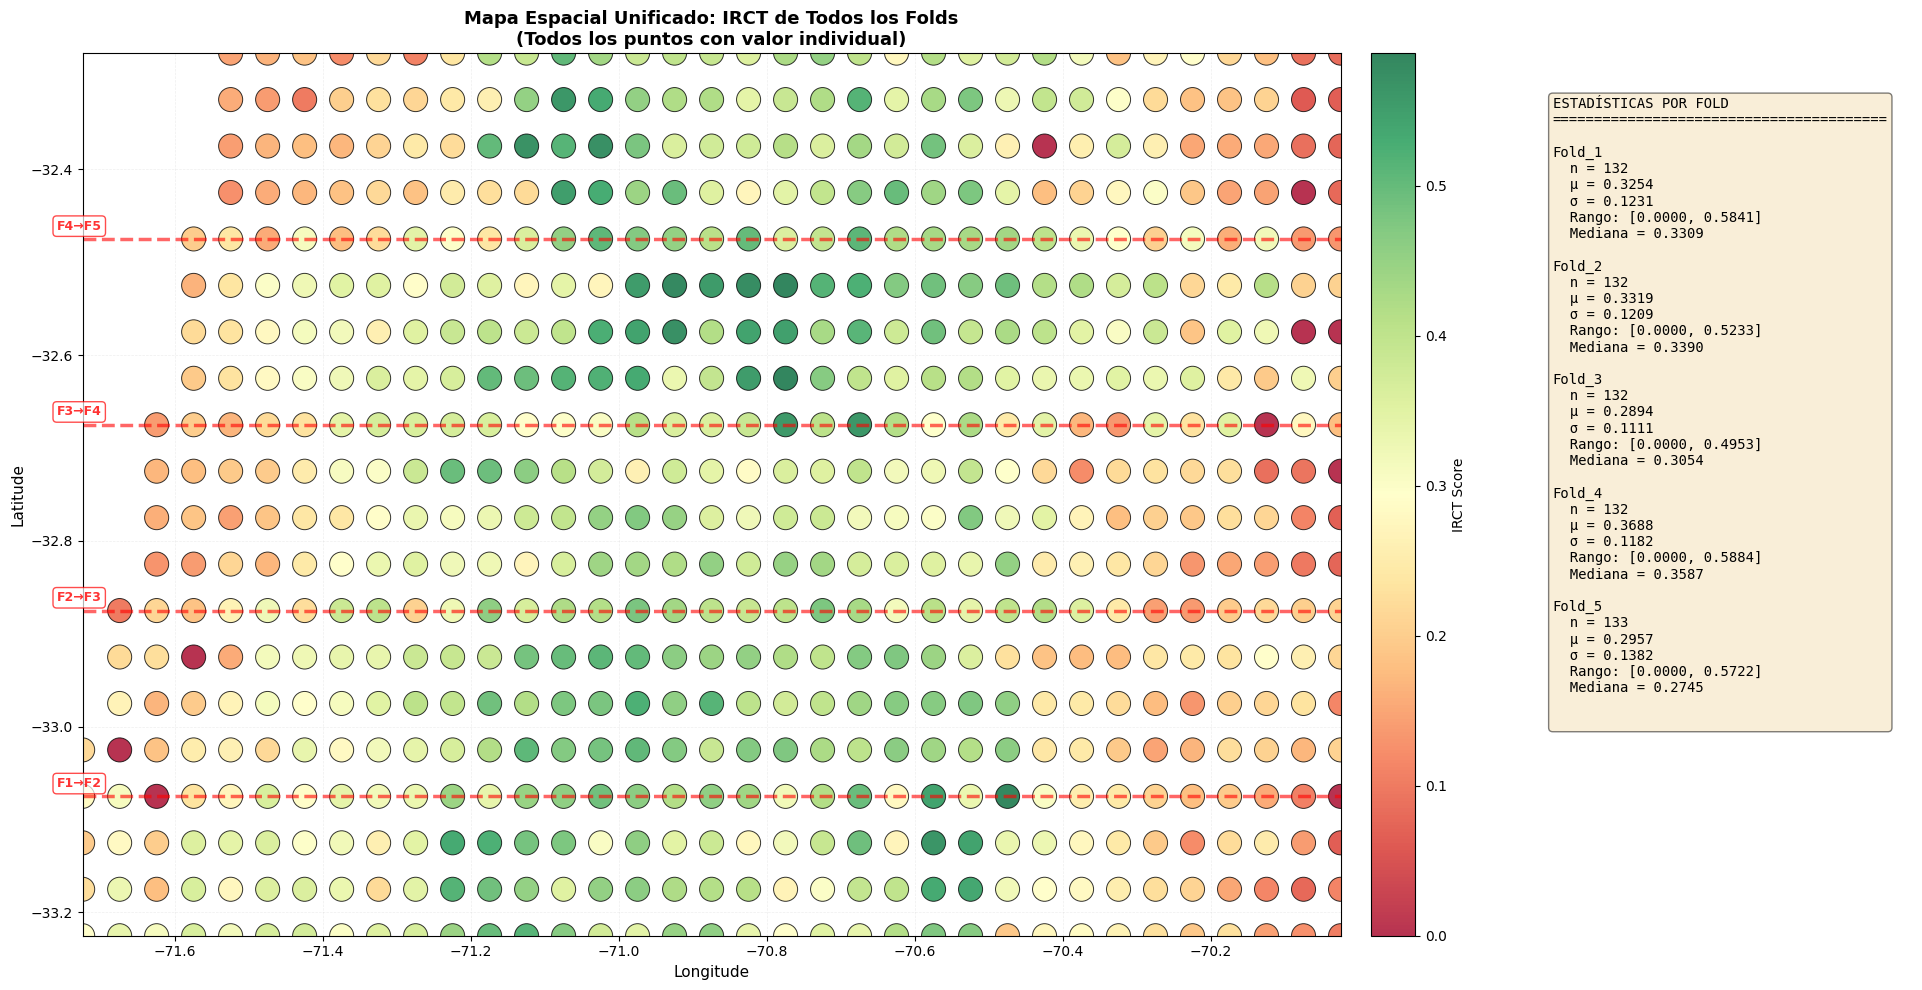

Mapa unificado suavizado de todos los folds guardado

Resumen: 5 folds organizados geográficamente (Sur→Norte)
  Fold_1: IRCT=0.3254 ± 0.1231
  Fold_2: IRCT=0.3319 ± 0.1209
  Fold_3: IRCT=0.2894 ± 0.1111
  Fold_4: IRCT=0.3688 ± 0.1182
  Fold_5: IRCT=0.2957 ± 0.1382


In [43]:
# Mapa unificado de todos los folds con puntos mejorados
fig, (ax_main, ax_legend) = plt.subplots(1, 2, figsize=(20, 10), 
                                         gridspec_kw={'width_ratios': [4, 1]})

# Rango global de datos
irt_global_min = np.min([r['irt_scores'].min() for r in cv_results])
irt_global_max = np.max([r['irt_scores'].max() for r in cv_results])

# Coordenadas y valores
lons = coords_base[:, 1]
lats = coords_base[:, 0]
lon_range = (lons.min(), lons.max())
lat_range = (lats.min(), lats.max())

# Scatter con puntos grandes y claros
scatter = ax_main.scatter(lons, lats, c=irt_full, cmap='RdYlGn', 
                         s=300, alpha=0.8, edgecolors='black', linewidths=0.7,
                         vmin=irt_global_min, vmax=irt_global_max)

ax_main.set_title('Mapa Espacial Unificado: IRCT de Todos los Folds\n(Todos los puntos con valor individual)', 
                  fontsize=13, fontweight='bold')
ax_main.set_xlabel('Longitude', fontsize=11)
ax_main.set_ylabel('Latitude', fontsize=11)
ax_main.set_xlim(lon_range)
ax_main.set_ylim(lat_range)
ax_main.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Agregar líneas divisorias entre folds (boundaries) con etiquetas
for fold_idx in range(1, N_FOLDS):
    lat_boundary = coords_base[folds[fold_idx], 0].min()
    ax_main.axhline(y=lat_boundary, color='red', linestyle='--', 
                   linewidth=2.5, alpha=0.6)
    ax_main.text(-71.76, lat_boundary + 0.01, f'F{fold_idx}→F{fold_idx+1}', 
                fontsize=9, color='red', alpha=0.8, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='red'))

# Colorbar global
cbar = plt.colorbar(scatter, ax=ax_main, label='IRCT Score', pad=0.02)

# Panel de leyenda con estadísticas por fold
ax_legend.axis('off')
legend_text = "ESTADÍSTICAS POR FOLD\n" + "="*40 + "\n\n"

for fold_idx, r in enumerate(cv_results):
    irt_scores = r['irt_scores']
    legend_text += (f"{r['fold_name']}\n"
                   f"  n = {len(irt_scores)}\n"
                   f"  μ = {np.mean(irt_scores):.4f}\n"
                   f"  σ = {np.std(irt_scores):.4f}\n"
                   f"  Rango: [{np.min(irt_scores):.4f}, {np.max(irt_scores):.4f}]\n"
                   f"  Mediana = {np.median(irt_scores):.4f}\n"
                   "\n")

ax_legend.text(0.05, 0.95, legend_text, transform=ax_legend.transAxes,
              fontsize=10, verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
try:
    plt.savefig(os.path.join(PLOTS_DIR, "spatial_cv_irt_unified_folds_map_smooth.png"), dpi=150, bbox_inches='tight', format='png')
except Exception as e:
    print(f"  Advertencia al guardar PNG: {e}")
    plt.savefig(os.path.join(PLOTS_DIR, "spatial_cv_irt_unified_folds_map_smooth.pdf"), bbox_inches='tight', format='pdf')
plt.show()

print("Mapa unificado suavizado de todos los folds guardado")
print(f"\nResumen: 5 folds organizados geográficamente (Sur→Norte)")
for fold_idx, r in enumerate(cv_results):
    print(f"  {r['fold_name']}: IRCT={np.mean(r['irt_scores']):.4f} ± {np.std(r['irt_scores']):.4f}")


## 18. Identificación de regiones de inestabilidad sistemática

In [44]:
print("\nIDENTIFICACIÓN DE REGIONES DE INESTABILIDAD SISTEMÁTICA")

print("\n1. Folds con menor estabilidad BASE→T585:")
stability_scores = [(r['fold_name'], r['stability']['ARI_T585']) for r in cv_results]
stability_scores_sorted = sorted(stability_scores, key=lambda x: x[1])

for fold_name, ari in stability_scores_sorted:
    print(f"  {fold_name}: ARI_T585 = {ari:.4f}")

print("\n2. Folds con mayor variabilidad interna (CV del IRCT):")
cv_scores = [(r['fold_name'], r['irt']['IRCT_CV']) for r in cv_results]
cv_scores_sorted = sorted(cv_scores, key=lambda x: x[1] if not np.isnan(x[1]) else -1, reverse=True)

for fold_name, cv in cv_scores_sorted:
    print(f"  {fold_name}: IRCT_CV = {cv:.4f}")

print("\n3. Folds con peor calidad de clustering (Silhouette):")
silhouette_scores = [(r['fold_name'], r['clustering']['silhouette']) for r in cv_results]
silhouette_scores_sorted = sorted(silhouette_scores, key=lambda x: x[1])

for fold_name, sil in silhouette_scores_sorted:
    print(f"  {fold_name}: Silhouette = {sil:.4f}")

print("\n4. Análisis de rangos latitudinales:")
for i, (r, fold_idx) in enumerate(zip(cv_results, folds)):
    coords_fold = coords_base[fold_idx]
    lat_range = (coords_fold[:, 0].min(), coords_fold[:, 0].max())
    ari = r['stability']['ARI_T585']
    irt_mean = r['irt']['IRCT_Mean']
    
    print(f"  {r['fold_name']}: Lat [{lat_range[0]:.4f}, {lat_range[1]:.4f}] - ARI={ari:.4f}, IRCT_Mean={irt_mean:.2f}")


IDENTIFICACIÓN DE REGIONES DE INESTABILIDAD SISTEMÁTICA

1. Folds con menor estabilidad BASE→T585:
  Fold_2: ARI_T585 = 0.4367
  Fold_5: ARI_T585 = 0.6890
  Fold_4: ARI_T585 = 0.8441
  Fold_1: ARI_T585 = 0.8852
  Fold_3: ARI_T585 = 0.9278

2. Folds con mayor variabilidad interna (CV del IRCT):
  Fold_5: IRCT_CV = 0.4673
  Fold_3: IRCT_CV = 0.3838
  Fold_1: IRCT_CV = 0.3785
  Fold_2: IRCT_CV = 0.3643
  Fold_4: IRCT_CV = 0.3205

3. Folds con peor calidad de clustering (Silhouette):
  Fold_5: Silhouette = 0.5653
  Fold_2: Silhouette = 0.5826
  Fold_1: Silhouette = 0.6329
  Fold_4: Silhouette = 0.6342
  Fold_3: Silhouette = 0.6652

4. Análisis de rangos latitudinales:
  Fold_1: Lat [-33.2250, -33.0750] - ARI=0.8852, IRCT_Mean=0.33
  Fold_2: Lat [-33.0750, -32.8750] - ARI=0.4367, IRCT_Mean=0.33
  Fold_3: Lat [-32.8750, -32.6750] - ARI=0.9278, IRCT_Mean=0.29
  Fold_4: Lat [-32.6750, -32.4750] - ARI=0.8441, IRCT_Mean=0.37
  Fold_5: Lat [-32.4750, -32.2750] - ARI=0.6890, IRCT_Mean=0.30


## 19. Coeficiente de variación de métricas clave


COEFICIENTE DE VARIACIÓN (CV) DE MÉTRICAS CLAVE

Interpretación:
  CV < 0.15: Baja variabilidad (modelo estable entre folds)
  0.15 <= CV < 0.30: Variabilidad moderada
  CV >= 0.30: Alta variabilidad (dependencia espacial fuerte)

Métrica                    Mean      Std       CV       Interpretación
--------------------------------------------------------------------------------
Silhouette                  0.6160    0.0367    0.0595  Estable
Calinski-Harabasz         357.2906   44.5561    0.1247  Estable
Davies-Bouldin              0.5021    0.0410    0.0817  Estable
Dunn                        0.9338    0.0733    0.0785  Estable
ARI_T585                    0.7566    0.1791    0.2368  Moderado
Jaccard_T585                0.4020    0.2535    0.6306  Inestable
Drift_T585                  2.1154    0.3380    0.1598  Moderado
Stability_T585              0.3246    0.0334    0.1028  Estable
IRCT_Mean                   0.3223    0.0285    0.0883  Estable
IRCT_Std                    0.1223  

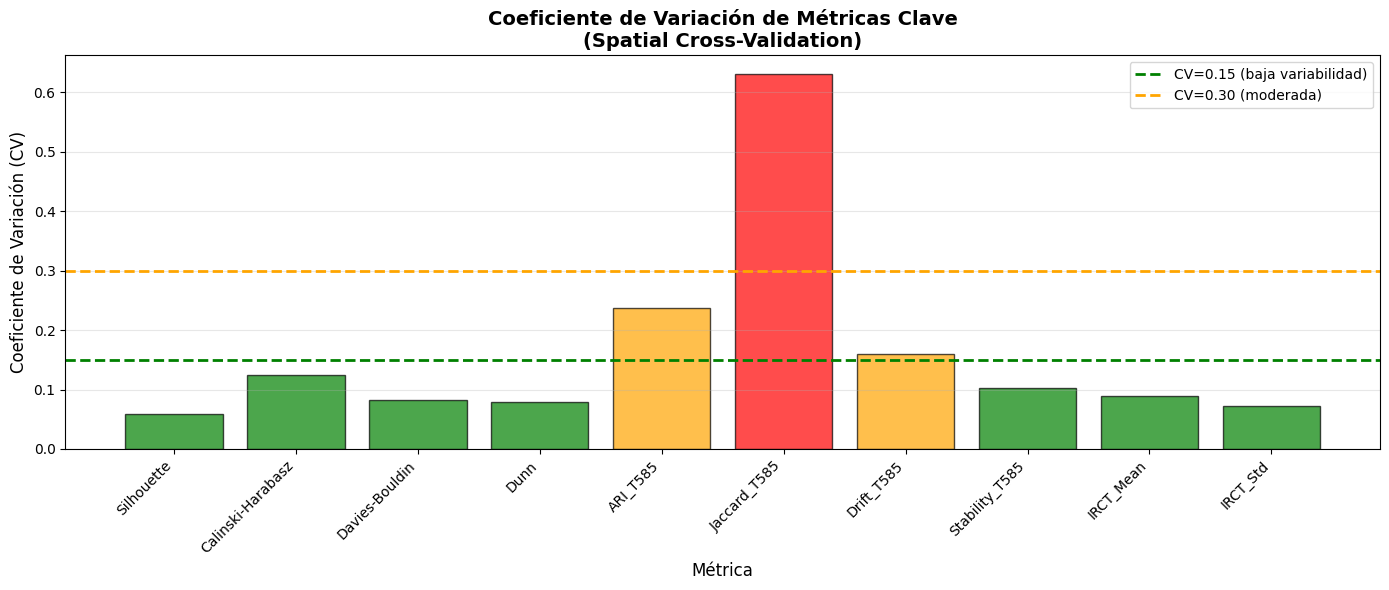


Gráfico de CV guardado


In [45]:
print("\nCOEFICIENTE DE VARIACIÓN (CV) DE MÉTRICAS CLAVE")
print("\nInterpretación:")
print("  CV < 0.15: Baja variabilidad (modelo estable entre folds)")
print("  0.15 <= CV < 0.30: Variabilidad moderada")
print("  CV >= 0.30: Alta variabilidad (dependencia espacial fuerte)")

cv_metrics = {}

key_metrics = [
    ('Silhouette', 'clustering', 'silhouette'),
    ('Calinski-Harabasz', 'clustering', 'calinski_harabasz'),
    ('Davies-Bouldin', 'clustering', 'davies_bouldin'),
    ('Dunn', 'clustering', 'dunn'),
    ('ARI_T585', 'stability', 'ARI_T585'),
    ('Jaccard_T585', 'stability', 'Avg_Jaccard_T585'),
    ('Drift_T585', 'stability', 'Avg_Drift_T585'),
    ('Stability_T585', 'stability', 'Avg_Stability_T585'),
    ('IRCT_Mean', 'irt', 'IRCT_Mean'),
    ('IRCT_Std', 'irt', 'IRCT_Std')
]

print("\nMétrica                    Mean      Std       CV       Interpretación")
print("-" * 80)

for name, metric_type, metric_key in key_metrics:
    values = metrics_summary[metric_type][metric_key]['values']
    mean_val = np.nanmean(values)
    std_val = np.nanstd(values)
    cv_val = std_val / mean_val if mean_val > 0 else np.nan
    
    cv_metrics[name] = cv_val
    
    if cv_val < 0.15:
        interpretation = "Estable"
    elif cv_val < 0.30:
        interpretation = "Moderado"
    else:
        interpretation = "Inestable"
    
    print(f"{name:25s} {mean_val:8.4f}  {std_val:8.4f}  {cv_val:8.4f}  {interpretation}")

fig, ax = plt.subplots(figsize=(14, 6))

metric_names = list(cv_metrics.keys())
cv_values = list(cv_metrics.values())

colors = ['green' if cv < 0.15 else 'orange' if cv < 0.30 else 'red' for cv in cv_values]

ax.bar(metric_names, cv_values, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(0.15, color='green', linestyle='--', linewidth=2, label='CV=0.15 (baja variabilidad)')
ax.axhline(0.30, color='orange', linestyle='--', linewidth=2, label='CV=0.30 (moderada)')

ax.set_title('Coeficiente de Variación de Métricas Clave\n(Spatial Cross-Validation)', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Coeficiente de Variación (CV)', fontsize=12)
ax.set_xlabel('Métrica', fontsize=12)
ax.set_xticklabels(metric_names, rotation=45, ha='right')
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "spatial_cv_coefficient_variation.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico de CV guardado")

## 20. Resumen ejecutivo de resultados

In [46]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO: VALIDACIÓN CRUZADA ESPACIAL")
print("="*80)

print(f"\nConfiguración: VAE + KMeans, K={K_CLUSTERS}, latent_dim={LATENT_DIM}, {N_FOLDS} folds")

print("\n1. CALIDAD DE CLUSTERING INTERNO (BASE):")
print(f"   Silhouette: {metrics_summary['clustering']['silhouette']['mean']:.4f} ± {metrics_summary['clustering']['silhouette']['std']:.4f}")
print(f"   Calinski-Harabasz: {metrics_summary['clustering']['calinski_harabasz']['mean']:.2f} ± {metrics_summary['clustering']['calinski_harabasz']['std']:.2f}")
print(f"   Davies-Bouldin: {metrics_summary['clustering']['davies_bouldin']['mean']:.4f} ± {metrics_summary['clustering']['davies_bouldin']['std']:.4f}")
print(f"   Dunn: {metrics_summary['clustering']['dunn']['mean']:.4f} ± {metrics_summary['clustering']['dunn']['std']:.4f}")

print("\n2. ESTABILIDAD BASE → T585:")
print(f"   ARI: {metrics_summary['stability']['ARI_T585']['mean']:.4f} ± {metrics_summary['stability']['ARI_T585']['std']:.4f}")
print(f"   Jaccard: {metrics_summary['stability']['Avg_Jaccard_T585']['mean']:.4f} ± {metrics_summary['stability']['Avg_Jaccard_T585']['std']:.4f}")
print(f"   Drift: {metrics_summary['stability']['Avg_Drift_T585']['mean']:.4f} ± {metrics_summary['stability']['Avg_Drift_T585']['std']:.4f}")
print(f"   Stability: {metrics_summary['stability']['Avg_Stability_T585']['mean']:.4f} ± {metrics_summary['stability']['Avg_Stability_T585']['std']:.4f}")

print("\n3. INDICADORES IRCT:")
print(f"   Mean: {metrics_summary['irt']['IRCT_Mean']['mean']:.2f} ± {metrics_summary['irt']['IRCT_Mean']['std']:.2f}")
print(f"   Std: {metrics_summary['irt']['IRCT_Std']['mean']:.2f} ± {metrics_summary['irt']['IRCT_Std']['std']:.2f}")
print(f"   CV: {metrics_summary['irt']['IRCT_CV']['mean']:.4f} ± {metrics_summary['irt']['IRCT_CV']['std']:.4f}")
print(f"   IQR: {metrics_summary['irt']['IRCT_IQR']['mean']:.2f} ± {metrics_summary['irt']['IRCT_IQR']['std']:.2f}")

print("\n4. VARIABILIDAD INTER-FOLD (CV):")
stable_metrics = [k for k, v in cv_metrics.items() if v < 0.15]
moderate_metrics = [k for k, v in cv_metrics.items() if 0.15 <= v < 0.30]
unstable_metrics = [k for k, v in cv_metrics.items() if v >= 0.30]

print(f"   Métricas estables (CV<0.15): {len(stable_metrics)}/{len(cv_metrics)}")
if stable_metrics:
    print(f"     {', '.join(stable_metrics)}")
print(f"   Métricas moderadas (0.15≤CV<0.30): {len(moderate_metrics)}/{len(cv_metrics)}")
if moderate_metrics:
    print(f"     {', '.join(moderate_metrics)}")
print(f"   Métricas inestables (CV≥0.30): {len(unstable_metrics)}/{len(cv_metrics)}")
if unstable_metrics:
    print(f"     {', '.join(unstable_metrics)}")

print("\n" + "="*80)


RESUMEN EJECUTIVO: VALIDACIÓN CRUZADA ESPACIAL

Configuración: VAE + KMeans, K=3, latent_dim=12, 5 folds

1. CALIDAD DE CLUSTERING INTERNO (BASE):
   Silhouette: 0.6160 ± 0.0367
   Calinski-Harabasz: 357.29 ± 44.56
   Davies-Bouldin: 0.5021 ± 0.0410
   Dunn: 0.9338 ± 0.0733

2. ESTABILIDAD BASE → T585:
   ARI: 0.7566 ± 0.1791
   Jaccard: 0.4020 ± 0.2535
   Drift: 2.1154 ± 0.3380
   Stability: 0.3246 ± 0.0334

3. INDICADORES IRCT:
   Mean: 0.32 ± 0.03
   Std: 0.12 ± 0.01
   CV: 0.3829 ± 0.0477
   IQR: 0.18 ± 0.03

4. VARIABILIDAD INTER-FOLD (CV):
   Métricas estables (CV<0.15): 7/10
     Silhouette, Calinski-Harabasz, Davies-Bouldin, Dunn, Stability_T585, IRCT_Mean, IRCT_Std
   Métricas moderadas (0.15≤CV<0.30): 2/10
     ARI_T585, Drift_T585
   Métricas inestables (CV≥0.30): 1/10
     Jaccard_T585



## 21. Conclusiones y respuestas a preguntas de investigación

In [47]:
print("\n" + "="*80)
print("CONCLUSIONES: VALIDACIÓN CRUZADA ESPACIAL")
print("="*80)

print("\n1. ¿El modelo generaliza entre regiones o depende de zonas específicas?")
print("-" * 80)

ari_cv = cv_metrics['ARI_T585']
silhouette_cv = cv_metrics['Silhouette']

if ari_cv < 0.15 and silhouette_cv < 0.15:
    print("✓ GENERALIZA BIEN: El modelo muestra baja variabilidad espacial")
    print(f"  - ARI CV: {ari_cv:.4f} (estable)")
    print(f"  - Silhouette CV: {silhouette_cv:.4f} (estable)")
    print("  - Interpretación: El VAE+KMeans es robusto y captura patrones globales")
elif ari_cv < 0.30 and silhouette_cv < 0.30:
    print("≈ GENERALIZA MODERADAMENTE: Variabilidad moderada entre regiones")
    print(f"  - ARI CV: {ari_cv:.4f}")
    print(f"  - Silhouette CV: {silhouette_cv:.4f}")
    print("  - Interpretación: Algunos folds muestran comportamiento diferenciado")
else:
    print("✗ DEPENDENCIA ESPACIAL FUERTE: Alta variabilidad entre regiones")
    print(f"  - ARI CV: {ari_cv:.4f}")
    print(f"  - Silhouette CV: {silhouette_cv:.4f}")
    print("  - Interpretación: El modelo es sensible a la ubicación geográfica")

print("\n2. ¿El IRT mantiene forma, rango y distribución entre folds?")
print("-" * 80)

irt_mean_cv = cv_metrics['IRT_Mean']
irt_std_cv = cv_metrics['IRT_Std']

avg_ks_pval = np.mean(overlap_matrix[np.triu_indices(N_FOLDS, k=1)])

print(f"  - CV del IRT_Mean: {irt_mean_cv:.4f}")
print(f"  - CV del IRT_Std: {irt_std_cv:.4f}")
print(f"  - KS test promedio (solapamiento): {avg_ks_pval:.6e}")

# Interpretación revisada: p-values bajos son ESPERADOS y BUENOS
if avg_ks_pval < 0.05:
    print("  ✓ HETEROGENEIDAD ESPACIAL DETECTADA: El IRT captura diferencias regionales")
    print("  - Las distribuciones son estadísticamente diferentes (p < 0.05)")
    print("  - Cada región geográfica tiene características climáticas distintivas")
    print("  - El IRT es un indicador sensible a la ubicación → útil para zonificación")
    print(f"  - Variabilidad de medias: {irt_mean_cv:.4f} ({'estable' if irt_mean_cv < 0.15 else 'moderada'})")
else:
    print("  ⚠ UNIFORMIDAD ESPACIAL INESPERADA: El IRT no discrimina entre regiones")
    print("  - Las distribuciones son similares (p > 0.05)")
    print("  - Puede indicar pérdida de información espacial en el modelo")
    print("  - Revisar si el VAE está colapsando características geográficas")

print("\n3. ¿Existen regiones que generan inestabilidad sistemática?")
print("-" * 80)

worst_fold = stability_scores_sorted[0]
best_fold = stability_scores_sorted[-1]

print(f"  - Fold más inestable: {worst_fold[0]} (ARI={worst_fold[1]:.4f})")
print(f"  - Fold más estable: {best_fold[0]} (ARI={best_fold[1]:.4f})")
print(f"  - Diferencia: {best_fold[1] - worst_fold[1]:.4f}")

if (best_fold[1] - worst_fold[1]) < 0.10:
    print("  ✓ HOMOGÉNEA: Todas las regiones tienen estabilidad similar")
else:
    print("  ✗ HETEROGÉNEA: Algunas regiones son sistemáticamente más inestables")
    print("  - Revisar características climáticas/geográficas de estas zonas")

print("\n4. ¿Cuál es el modelo más robusto para un IRT territorial?")
print("-" * 80)

mean_ari = metrics_summary['stability']['ARI_T585']['mean']
mean_silhouette = metrics_summary['clustering']['silhouette']['mean']
mean_irt = metrics_summary['irt']['IRT_Mean']['mean']

print(f"  Configuración evaluada: VAE + KMeans (K={K_CLUSTERS}, latent_dim={LATENT_DIM})")
print(f"  - ARI promedio: {mean_ari:.4f}")
print(f"  - Silhouette promedio: {mean_silhouette:.4f}")
print(f"  - IRT promedio: {mean_irt:.2f}")

robustness_score = (
    (1.0 if ari_cv < 0.15 else 0.5 if ari_cv < 0.30 else 0.0) +
    (1.0 if silhouette_cv < 0.15 else 0.5 if silhouette_cv < 0.30 else 0.0) +
    (1.0 if irt_mean_cv < 0.15 else 0.5 if irt_mean_cv < 0.30 else 0.0)
) / 3.0

print(f"  - Robustness Score: {robustness_score:.2f}/1.00")

if robustness_score >= 0.75:
    print("  ✓ ALTA ROBUSTEZ: Configuración recomendada para IRT territorial")
elif robustness_score >= 0.50:
    print("  ≈ ROBUSTEZ MODERADA: Configuración utilizable con precauciones")
else:
    print("  ✗ BAJA ROBUSTEZ: Considerar ajustes en arquitectura o hiperparámetros")

print("\n" + "="*80)


CONCLUSIONES: VALIDACIÓN CRUZADA ESPACIAL

1. ¿El modelo generaliza entre regiones o depende de zonas específicas?
--------------------------------------------------------------------------------
≈ GENERALIZA MODERADAMENTE: Variabilidad moderada entre regiones
  - ARI CV: 0.2368
  - Silhouette CV: 0.0595
  - Interpretación: Algunos folds muestran comportamiento diferenciado

2. ¿El IRT mantiene forma, rango y distribución entre folds?
--------------------------------------------------------------------------------


KeyError: 'IRT_Mean'